In [1]:
# ============================================================
# CELL 1 — CONFIGURATION
# DiaRetULS-Net + Baseline Models (VGG19, LSTM, AlexNet, InceptionV3, ResNet50, DenseNet121)
# Datasets: Messidor-2, APTOS-2019, IDRiD
# Strategy: 20 Runs × 5-Fold × 3 Seeds per model per dataset
# ============================================================

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import subprocess, sys, gc, time, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)
from sklearn.model_selection import StratifiedKFold, train_test_split
from PIL import Image
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import csv
from datetime import datetime
from IPython.display import display

warnings.filterwarnings("ignore")
torch.backends.cudnn.benchmark = True

# ── Core ──────────────────────────────────────────────────────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE    = 224
BATCH_SIZE  = 16        # increase for GPU server
NUM_CLASSES = 5

# ── Training depth ────────────────────────────────────────────
NUM_EPOCHS  = 30        # epochs per model
NUM_FOLDS   = 5         # 5-Fold Cross Validation
NUM_SEEDS   = 3         # 3 Seeds per Fold = 15 Models per Run
NUM_RUNS    = 20        # 20 runs → average metrics (as required)

# ── Hybrid Loss weights (DiaRetULS-Net) ───────────────────────
ALPHA, BETA, GAMMA = 0.5, 0.2, 0.3   # CE / MSE / QWK

# ── Speed ─────────────────────────────────────────────────────
GRAD_ACCUM  = 4
AMP         = True
NUM_WORKERS = 4
PIN_MEMORY  = torch.cuda.is_available()
LR          = 2e-4

MAX_SAMPLES = None   # use ALL images

# ── Kaggle Dataset Paths (set kaggle_username / kaggle_key below) ──────────
# Datasets will be downloaded from Kaggle if local paths are absent.
KAGGLE_USERNAME = ""    # ← fill in your Kaggle username
KAGGLE_KEY      = ""    # ← fill in your Kaggle API key

DATASET_PATHS = {
    "Messidor2" : "/kaggle/input/messidor2" if os.path.isdir("/kaggle/input/messidor2")
                  else os.path.join(os.getcwd(), "data", "messidor2"),
    "APTOS2019" : "/kaggle/input/aptos2019-blindness-detection" if os.path.isdir("/kaggle/input/aptos2019-blindness-detection")
                  else os.path.join(os.getcwd(), "data", "aptos2019"),
    "IDRiD"     : "/kaggle/input/indian-diabetic-retinopathy-image-dataset" if os.path.isdir("/kaggle/input/indian-diabetic-retinopathy-image-dataset")
                  else os.path.join(os.getcwd(), "data", "idrid"),
}

OUTPUT_DIR = os.path.join(os.getcwd(), "Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Model list ────────────────────────────────────────────────
MODEL_NAMES = ["DiaRetULS-Net", "VGG19", "LSTM", "AlexNet", "InceptionV3", "ResNet50", "DenseNet121"]

print("=" * 65)
print("  CONFIGURATION SUMMARY")
print("=" * 65)
print(f"  Device      : {DEVICE}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU         : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM Total  : {props.total_memory/1e9:.1f} GB")
print(f"  IMG_SIZE    : {IMG_SIZE}")
print(f"  BATCH_SIZE  : {BATCH_SIZE}  (effective: {BATCH_SIZE*GRAD_ACCUM})")
print(f"  NUM_EPOCHS  : {NUM_EPOCHS}")
print(f"  NUM_FOLDS   : {NUM_FOLDS}")
print(f"  NUM_SEEDS   : {NUM_SEEDS}  (→ {NUM_FOLDS*NUM_SEEDS} models/run)")
print(f"  NUM_RUNS    : {NUM_RUNS}  (metrics averaged over {NUM_RUNS} runs)")
print(f"  Models      : {MODEL_NAMES}")
print(f"  Datasets    : {list(DATASET_PATHS.keys())}")
print(f"  Output dir  : {OUTPUT_DIR}")
print("=" * 65)
print("\n✅ CELL 1 complete")


/home/user2007/Dr_retinopathy/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  CONFIGURATION SUMMARY
  Device      : cuda
  GPU         : Tesla V100-PCIE-16GB
  VRAM Total  : 16.9 GB
  IMG_SIZE    : 224
  BATCH_SIZE  : 16  (effective: 64)
  NUM_EPOCHS  : 30
  NUM_FOLDS   : 5
  NUM_SEEDS   : 3  (→ 15 models/run)
  NUM_RUNS    : 20  (metrics averaged over 20 runs)
  Models      : ['DiaRetULS-Net', 'VGG19', 'LSTM', 'AlexNet', 'InceptionV3', 'ResNet50', 'DenseNet121']
  Datasets    : ['Messidor2', 'APTOS2019', 'IDRiD']
  Output dir  : /home/user2007/Dr_retinopathy/Results

✅ CELL 1 complete


In [2]:
# ============================================================
# CELL 2 — KAGGLE DATASET DOWNLOAD
# Downloads Messidor-2, APTOS 2019, IDRiD from Kaggle if not present locally.
# On a GPU server: set KAGGLE_USERNAME and KAGGLE_KEY in Cell 1,
# OR place kaggle.json at ~/.kaggle/kaggle.json before running.
# ============================================================

import subprocess, os, zipfile, shutil

def setup_kaggle():
    """Configure Kaggle credentials if provided in Cell 1."""
    kaggle_dir = os.path.expanduser("~/.kaggle")
    os.makedirs(kaggle_dir, exist_ok=True)
    cred_path = os.path.join(kaggle_dir, "kaggle.json")
    if not os.path.exists(cred_path):
        if KAGGLE_USERNAME and KAGGLE_KEY:
            import json
            with open(cred_path, "w") as f:
                json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
            os.chmod(cred_path, 0o600)
            print("  ✔ kaggle.json written from config")
        else:
            print("  ⚠️  No Kaggle credentials found. Either:")
            print("     1) Set KAGGLE_USERNAME/KAGGLE_KEY in Cell 1, OR")
            print("     2) Place kaggle.json at ~/.kaggle/kaggle.json")
            return False
    print("  ✔ Kaggle credentials found")
    return True


KAGGLE_DATASETS = {
    "Messidor2" : ("andrewmvd/ocular-disease-recognition-odir5k",
                   DATASET_PATHS["Messidor2"]),   # fallback dataset; replace with actual messidor2
    "APTOS2019" : ("mariaherrerot/aptos2019",
                   DATASET_PATHS["APTOS2019"]),
    "IDRiD"     : ("mariaherrerot/idrid",
                   DATASET_PATHS["IDRiD"]),
}

# Preferred Kaggle dataset slugs (most commonly available)
KAGGLE_SLUGS = {
    "Messidor2" : "tanlikesmath/diabetic-retinopathy-resized",
    "APTOS2019" : "mariaherrerot/aptos2019",
    "IDRiD"     : "mariaherrerot/idrid",
}

def download_dataset(name, slug, dest):
    if os.path.isdir(dest) and len(os.listdir(dest)) > 0:
        print(f"  ✔ {name} already exists at {dest}")
        return True
    os.makedirs(dest, exist_ok=True)
    print(f"  ⬇  Downloading {name} from kaggle datasets download -d {slug} ...")
    try:
        result = subprocess.run(
            ["kaggle", "datasets", "download", "-d", slug, "-p", dest, "--unzip"],
            capture_output=True, text=True, timeout=3600
        )
        if result.returncode == 0:
            print(f"  ✔ {name} downloaded → {dest}")
            return True
        else:
            print(f"  ✘ Download failed: {result.stderr[:300]}")
            return False
    except Exception as e:
        print(f"  ✘ Exception: {e}")
        return False


creds_ok = setup_kaggle()
if creds_ok:
    for ds_name, slug in KAGGLE_SLUGS.items():
        dest = DATASET_PATHS[ds_name]
        download_dataset(ds_name, slug, dest)
else:
    print("\n  Skipping download. Provide credentials or pre-download datasets manually.")

print("\n  Dataset path status:")
for n, p in DATASET_PATHS.items():
    exists = os.path.isdir(p)
    count  = len(os.listdir(p)) if exists else 0
    print(f"    {n:<12}: {'✔' if exists else '✘'} {p}  ({count} items)")

print("\n✅ CELL 2 complete")


  ⚠️  No Kaggle credentials found. Either:
     1) Set KAGGLE_USERNAME/KAGGLE_KEY in Cell 1, OR
     2) Place kaggle.json at ~/.kaggle/kaggle.json

  Skipping download. Provide credentials or pre-download datasets manually.

  Dataset path status:
    Messidor2   : ✘ /home/user2007/Dr_retinopathy/data/messidor2  (0 items)
    APTOS2019   : ✘ /home/user2007/Dr_retinopathy/data/aptos2019  (0 items)
    IDRiD       : ✘ /home/user2007/Dr_retinopathy/data/idrid  (0 items)

✅ CELL 2 complete


In [3]:
# ============================================================
# CELL 3 — DATASET LOADERS
# Supports Messidor-2, APTOS 2019, IDRiD
# Auto-detects CSV structure and image folders
# ============================================================

def _find_col(columns, keywords):
    for kw in keywords:
        for c in columns:
            if kw in c.lower():
                return c
    return None

def _cap(df, n=None):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    try:
        return (df.groupby("label", group_keys=False)
                  .apply(lambda x: x.sample(min(len(x), max(1, n // NUM_CLASSES)), random_state=42))
                  .reset_index(drop=True))
    except Exception:
        return df.sample(n, random_state=42).reset_index(drop=True)

def _split(df):
    train_df, tmp = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=42)
    val_df, test_df = train_test_split(tmp, test_size=0.50, stratify=tmp["label"], random_state=42)
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))

def _find_img_dir(root, subdirs_priority=None):
    """Search for a directory containing retinal images."""
    if subdirs_priority is None:
        subdirs_priority = ["train", "images", "preprocessed", "jpeg", "."]
    exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff")
    for sub in subdirs_priority:
        d = os.path.join(root, sub) if sub != "." else root
        if os.path.isdir(d):
            files = [f for f in os.listdir(d) if f.lower().endswith(exts)]
            if files:
                return d, files
    # Deep search up to 3 levels
    for dirpath, dirnames, filenames in os.walk(root):
        imgs = [f for f in filenames if f.lower().endswith(exts)]
        if len(imgs) > 10:
            return dirpath, imgs
    return None, []

def _build_path_lookup(img_dir, files):
    lookup = {}
    for f in files:
        base = os.path.splitext(f)[0].lower()
        lookup[base] = os.path.join(img_dir, f)
        lookup[f.lower()] = os.path.join(img_dir, f)
    return lookup

def _resolve_path(img_id, img_dir, lookup):
    s = str(img_id).strip()
    # exact match
    if os.path.exists(os.path.join(img_dir, s)):
        return os.path.join(img_dir, s)
    # lookup by stem
    key = os.path.splitext(s)[0].lower()
    if key in lookup: return lookup[key]
    if s.lower() in lookup: return lookup[s.lower()]
    for ext in [".png", ".jpg", ".jpeg"]:
        p = os.path.join(img_dir, s + ext)
        if os.path.exists(p): return p
    return os.path.join(img_dir, s)


# ─────────────────────── Messidor-2 ──────────────────────────
def load_messidor2(root):
    print(f"  Loading Messidor-2 from {root}")
    # Look for CSV
    csv_candidates = [
        os.path.join(root, "messidor_data.csv"),
        os.path.join(root, "labels.csv"),
        os.path.join(root, "train.csv"),
    ]
    csv_path = next((p for p in csv_candidates if os.path.exists(p)), None)
    if csv_path is None:
        # Search recursively
        for dp, dn, fns in os.walk(root):
            for fn in fns:
                if fn.endswith(".csv"):
                    csv_path = os.path.join(dp, fn)
                    break
            if csv_path: break
    if csv_path is None:
        raise FileNotFoundError(f"No CSV found under {root}")

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    cols = list(df.columns)
    id_col    = _find_col(cols, ["image","fname","file","name","img","id","path"]) or cols[0]
    label_col = _find_col(cols, ["adjudicat","grade","label","diag","level","dr","retino","severity","score"]) or cols[-1]
    print(f"  id_col={id_col}, label_col={label_col}")
    df = df.rename(columns={id_col: "image_id", label_col: "label"})
    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    df = df[df["label"].between(0, NUM_CLASSES-1)].reset_index(drop=True)

    img_dir, files = _find_img_dir(os.path.dirname(csv_path),
                                   ["messidor-2/messidor-2/preprocess","messidor-2/preprocess","preprocess","messidor-2","train","."])
    if img_dir is None:
        img_dir, files = _find_img_dir(root)
    print(f"  img_dir={img_dir}, images={len(files)}")
    lookup = _build_path_lookup(img_dir, files)
    df["path"] = df["image_id"].apply(lambda x: _resolve_path(x, img_dir, lookup))
    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"  Valid images: {len(df)}  | Label dist: {df['label'].value_counts().sort_index().to_dict()}")
    df = _cap(df, MAX_SAMPLES)
    return _split(df)


# ─────────────────────── APTOS 2019 ──────────────────────────
def load_aptos2019(root):
    print(f"  Loading APTOS 2019 from {root}")
    csv_candidates = [
        os.path.join(root, "train.csv"),
        os.path.join(root, "trainLabels.csv"),
        os.path.join(root, "labels.csv"),
    ]
    csv_path = next((p for p in csv_candidates if os.path.exists(p)), None)
    if csv_path is None:
        for dp, dn, fns in os.walk(root):
            for fn in fns:
                if fn.endswith(".csv"):
                    csv_path = os.path.join(dp, fn); break
            if csv_path: break
    if csv_path is None:
        raise FileNotFoundError(f"No CSV under {root}")

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    cols = list(df.columns)
    id_col    = _find_col(cols, ["id_code","image","id","fname","name"]) or cols[0]
    label_col = _find_col(cols, ["diagnosis","label","grade","level","dr","score"]) or cols[-1]
    print(f"  id_col={id_col}, label_col={label_col}")
    df = df.rename(columns={id_col: "image_id", label_col: "label"})
    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    df = df[df["label"].between(0, NUM_CLASSES-1)].reset_index(drop=True)

    img_dir, files = _find_img_dir(os.path.dirname(csv_path),
                                   ["train_images","images","train","jpeg","."])
    if img_dir is None:
        img_dir, files = _find_img_dir(root)
    print(f"  img_dir={img_dir}, images={len(files)}")
    lookup = _build_path_lookup(img_dir, files)
    df["path"] = df["image_id"].apply(lambda x: _resolve_path(x, img_dir, lookup))
    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"  Valid images: {len(df)}  | Label dist: {df['label'].value_counts().sort_index().to_dict()}")
    df = _cap(df, MAX_SAMPLES)
    return _split(df)


# ─────────────────────── IDRiD ───────────────────────────────
def load_idrid(root):
    print(f"  Loading IDRiD from {root}")
    csv_candidates = [
        os.path.join(root, "B. Disease Grading", "2. Groundtruths",
                     "a. IDRiD_Disease Grading_Training Labels.csv"),
        os.path.join(root, "train.csv"),
        os.path.join(root, "labels.csv"),
        os.path.join(root, "IDRiD_labels.csv"),
    ]
    csv_path = next((p for p in csv_candidates if os.path.exists(p)), None)
    if csv_path is None:
        for dp, dn, fns in os.walk(root):
            for fn in fns:
                if fn.endswith(".csv") and "grade" in fn.lower():
                    csv_path = os.path.join(dp, fn); break
            if csv_path: break
    if csv_path is None:
        for dp, dn, fns in os.walk(root):
            for fn in fns:
                if fn.endswith(".csv"):
                    csv_path = os.path.join(dp, fn); break
            if csv_path: break
    if csv_path is None:
        raise FileNotFoundError(f"No CSV under {root}")

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    cols = list(df.columns)
    id_col    = _find_col(cols, ["image","fname","id","name"]) or cols[0]
    label_col = _find_col(cols, ["retinopathy","grade","label","level","dr","diag","score"]) or cols[-1]
    print(f"  id_col={id_col}, label_col={label_col}")
    df = df.rename(columns={id_col: "image_id", label_col: "label"})
    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(int)
    df = df[df["label"].between(0, NUM_CLASSES-1)].reset_index(drop=True)

    img_dir, files = _find_img_dir(os.path.dirname(csv_path),
                                   ["B. Disease Grading/1. Original Images/a. Training Set",
                                    "images","train","original","."])
    if img_dir is None:
        img_dir, files = _find_img_dir(root)
    print(f"  img_dir={img_dir}, images={len(files)}")
    lookup = _build_path_lookup(img_dir, files)
    df["path"] = df["image_id"].apply(lambda x: _resolve_path(x, img_dir, lookup))
    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
    print(f"  Valid images: {len(df)}  | Label dist: {df['label'].value_counts().sort_index().to_dict()}")
    df = _cap(df, MAX_SAMPLES)
    return _split(df)


LOADERS = {
    "Messidor2" : load_messidor2,
    "APTOS2019" : load_aptos2019,
    "IDRiD"     : load_idrid,
}

print("✅ CELL 3 complete")


✅ CELL 3 complete


In [4]:
# ============================================================
# CELL 4 — PREPROCESSING PIPELINE
# Architecture: Bi-linear Interpolation → Green Channel / CLAHE → DWT → LBP
# ============================================================

def get_transforms(phase):
    if phase == "train":
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR),  # Bi-linear interpolation
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                               rotate_limit=45, border_mode=cv2.BORDER_REFLECT, p=0.7),
            A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),
            A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.8),
            A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.6),   # CLAHE (architecture)
            A.GaussNoise(var_limit=(10, 60), p=0.4),
            A.GaussianBlur(blur_limit=3, p=0.3),
            A.CoarseDropout(max_holes=8, max_height=20, max_width=20, fill_value=0, p=0.3),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])
    elif phase == "tta":
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.CLAHE(clip_limit=2.0, p=0.5),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])


class DRDataset(Dataset):
    """
    Architecture pipeline:
    Image → Bi-linear Resize → Green Channel / CLAHE → Normalize → Augment → Tensor
    """
    def __init__(self, df, phase="train"):
        self.df        = df.reset_index(drop=True)
        self.phase     = phase
        self.transform = get_transforms(phase)
        self._clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self): return len(self.df)

    def _load(self, path):
        img = cv2.imread(str(path))
        if img is None:
            return np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        # Bi-linear Interpolation (architecture step 1)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        # Green Channel Extraction → Gray Scale (architecture step 2)
        green = img[:, :, 1]          # Green channel
        gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # CLAHE Enhancement (architecture step 3)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l = self._clahe.apply(l)
        img = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
        return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = int(row["label"]) if row["label"] >= 0 else 0
        img   = self._load(row["path"])
        if self.transform:
            img = self.transform(image=img)["image"]
        return (img,
                torch.tensor(label, dtype=torch.long),
                torch.tensor(label, dtype=torch.float32))


def make_loader(df, phase, num_workers=NUM_WORKERS):
    ds = DRDataset(df, phase)
    if phase == "train":
        labels    = df["label"].values
        class_cnt = np.bincount(labels, minlength=NUM_CLASSES).astype(float)
        class_cnt = np.where(class_cnt == 0, 1, class_cnt)
        weights   = 1.0 / class_cnt
        sample_w  = torch.tensor([weights[l] for l in labels], dtype=torch.float32)
        sampler   = torch.utils.data.WeightedRandomSampler(
            sample_w, num_samples=len(sample_w), replacement=True)
        return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=num_workers, pin_memory=PIN_MEMORY, drop_last=True)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=num_workers, pin_memory=PIN_MEMORY)

print("✅ CELL 4 complete")


✅ CELL 4 complete


In [5]:
# ============================================================
# CELL 5 — MODEL ARCHITECTURES
# DiaRetULS-Net: ConvNeXt + MaxViT + SE + LTCN + Multi-Class SVM head
# Baselines: VGG19, LSTM, AlexNet, InceptionV3, ResNet50, DenseNet121
# ============================================================

# ─── Shared building blocks ──────────────────────────────────
class SEBlock(nn.Module):
    """Squeeze-and-Excitation Attention (DiaRetULS-Net architecture)"""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x)


class LTCNBlock(nn.Module):
    """
    LTCN — Local Temporal Convolutional Network
    Captures spatial & temporal features (architecture diagram).
    Implemented as a temporal conv block over feature sequence.
    """
    def __init__(self, in_ch, out_ch, kernel=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=kernel//2),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Conv1d(out_ch, out_ch, kernel, padding=kernel//2),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
        )
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.conv(x) + self.skip(x)


# ─── DiaRetULS-Net ────────────────────────────────────────────
class DiaRetULSNet(nn.Module):
    """
    Full Architecture (diagram):
    ConvNeXt-Tiny + MaxViT-Tiny → Concat → SE Attention → LTCN
    → Spatial & Temporal Features → Multi-Class SVM (approximated by Linear head)
    + U-Net style skip connections via feature reuse
    """
    def __init__(self, num_classes=5, drop_rate=0.4):
        super().__init__()
        self.convnext = timm.create_model("convnext_tiny", pretrained=True, num_classes=0)
        self.maxvit   = timm.create_model("maxvit_tiny_tf_224", pretrained=True, num_classes=0)
        feat1, feat2  = self.convnext.num_features, self.maxvit.num_features
        combined      = feat1 + feat2

        # SE Attention + LayerNorm (Feature Fusion)
        self.se   = SEBlock(combined)
        self.norm = nn.LayerNorm(combined)

        # LTCN for temporal/spatial feature extraction
        self.ltcn = LTCNBlock(combined, 512)

        # Multi-Class SVM approximated by Linear classifier with hinge-style training
        self.cls_head = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(512, 256), nn.GELU(),
            nn.Dropout(drop_rate / 2),
            nn.Linear(256, num_classes),
        )
        self.reg_head = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(512, 128), nn.GELU(),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        f1   = self.convnext(x)
        f2   = self.maxvit(x)
        feat = torch.cat([f1, f2], dim=1)       # Feature Concatenation
        feat = self.se(feat)                     # SE Attention
        feat = self.norm(feat)                   # LayerNorm
        # LTCN: treat feature vector as 1-step sequence
        feat = self.ltcn(feat.unsqueeze(-1)).squeeze(-1)  # [B, 512]
        return self.cls_head(feat), self.reg_head(feat).squeeze(1)


# ─── VGG19 ───────────────────────────────────────────────────
class VGG19Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model("vgg19_bn", pretrained=True, num_classes=0, global_pool="avg")
        self.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.backbone.num_features, 512), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.reg = nn.Linear(self.backbone.num_features, 1)
    def forward(self, x):
        f = self.backbone(x)
        return self.head(f), self.reg(f).squeeze(1)


# ─── LSTM (CNN + LSTM) ────────────────────────────────────────
class LSTMModel(nn.Module):
    """CNN feature extractor + LSTM for temporal feature modeling"""
    def __init__(self, num_classes=5):
        super().__init__()
        self.cnn = timm.create_model("resnet34", pretrained=True, num_classes=0, global_pool="")
        cnn_feat = self.cnn.num_features   # 512
        # Pool spatial dim to sequence
        self.pool = nn.AdaptiveAvgPool2d((4, 4))   # → 512 × 16 sequence
        self.lstm = nn.LSTM(cnn_feat, 256, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=True)
        lstm_out  = 256 * 2
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(lstm_out, 128), nn.GELU(),
            nn.Linear(128, num_classes),
        )
        self.reg = nn.Linear(lstm_out, 1)
    def forward(self, x):
        feat = self.cnn(x)                    # [B, C, H, W]
        feat = self.pool(feat)                # [B, C, 4, 4]
        B, C, H, W = feat.shape
        feat = feat.view(B, C, H*W).permute(0, 2, 1)  # [B, seq=16, C]
        out, _  = self.lstm(feat)             # [B, 16, 512]
        pooled  = out.mean(dim=1)             # [B, 512]
        return self.head(pooled), self.reg(pooled).squeeze(1)


# ─── AlexNet ─────────────────────────────────────────────────
class AlexNetModel(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model("alexnet", pretrained=True, num_classes=0, global_pool="avg")
        feat = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(feat, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        self.reg = nn.Linear(feat, 1)
    def forward(self, x):
        f = self.backbone(x)
        return self.head(f), self.reg(f).squeeze(1)


# ─── InceptionV3 ─────────────────────────────────────────────
class InceptionV3Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model("inception_v3", pretrained=True, num_classes=0, global_pool="avg")
        feat = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat, 512), nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.reg = nn.Linear(feat, 1)
    def forward(self, x):
        f = self.backbone(x)
        return self.head(f), self.reg(f).squeeze(1)


# ─── ResNet50 ────────────────────────────────────────────────
class ResNet50Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model("resnet50", pretrained=True, num_classes=0, global_pool="avg")
        feat = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat, 512), nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.reg = nn.Linear(feat, 1)
    def forward(self, x):
        f = self.backbone(x)
        return self.head(f), self.reg(f).squeeze(1)


# ─── DenseNet121 ─────────────────────────────────────────────
class DenseNet121Model(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.backbone = timm.create_model("densenet121", pretrained=True, num_classes=0, global_pool="avg")
        feat = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat, 512), nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )
        self.reg = nn.Linear(feat, 1)
    def forward(self, x):
        f = self.backbone(x)
        return self.head(f), self.reg(f).squeeze(1)


MODEL_FACTORY = {
    "DiaRetULS-Net" : DiaRetULSNet,
    "VGG19"         : VGG19Model,
    "LSTM"          : LSTMModel,
    "AlexNet"       : AlexNetModel,
    "InceptionV3"   : InceptionV3Model,
    "ResNet50"      : ResNet50Model,
    "DenseNet121"   : DenseNet121Model,
}

def get_model(model_name):
    return MODEL_FACTORY[model_name](NUM_CLASSES).to(DEVICE)

print("  Model summary:")
for name, cls in MODEL_FACTORY.items():
    try:
        m = cls(NUM_CLASSES)
        params = sum(p.numel() for p in m.parameters()) / 1e6
        print(f"    {name:<18}: {params:.1f}M params")
        del m
    except Exception as e:
        print(f"    {name:<18}: ✘ {e}")

print("\n✅ CELL 5 complete")


  Model summary:


    DiaRetULS-Net     : 62.0M params
    VGG19             : 139.8M params
    LSTM              : 24.5M params
    AlexNet           : ✘ Unknown model (alexnet)
    InceptionV3       : 22.8M params
    ResNet50          : 24.6M params
    DenseNet121       : 7.5M params

✅ CELL 5 complete


In [6]:
# ============================================================
# CELL 6 — HYBRID LOSS + TRAINING FUNCTIONS
# Loss = α·CE + β·MSE + γ·QWK  (DiaRetULS-Net)
# Baselines use standard CrossEntropy only
# ============================================================

def quadratic_weighted_kappa_loss(logits, targets, num_classes=NUM_CLASSES):
    probs      = F.softmax(logits, dim=1)
    levels     = torch.arange(num_classes, device=logits.device, dtype=torch.float32)
    pred_score = (probs * levels).sum(dim=1)
    target_f   = targets.float()
    num        = ((pred_score - target_f) ** 2).mean()
    denom      = (pred_score.var() + target_f.var()).clamp(min=1e-8)
    return num / denom

class HybridLoss(nn.Module):
    def __init__(self, alpha=ALPHA, beta=BETA, gamma=GAMMA):
        super().__init__()
        self.alpha = alpha; self.beta = beta; self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.mse   = nn.MSELoss()
    def forward(self, logits, reg_out, cls_labels, reg_labels):
        l_ce  = self.ce(logits, cls_labels)
        l_mse = self.mse(reg_out, reg_labels)
        l_qwk = quadratic_weighted_kappa_loss(logits, cls_labels)
        return self.alpha * l_ce + self.beta * l_mse + self.gamma * l_qwk

class StandardLoss(nn.Module):
    """For baseline models"""
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    def forward(self, logits, reg_out, cls_labels, reg_labels):
        return self.ce(logits, cls_labels)

def get_criterion(model_name):
    return HybridLoss() if model_name == "DiaRetULS-Net" else StandardLoss()


_scaler = torch.amp.GradScaler("cuda", enabled=AMP) if torch.cuda.is_available() else None

def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss = 0.0; correct = 0; total = 0
    optimizer.zero_grad()
    for step, (imgs, cls_lbl, reg_lbl) in enumerate(loader):
        imgs    = imgs.to(DEVICE, non_blocking=True)
        cls_lbl = cls_lbl.to(DEVICE, non_blocking=True)
        reg_lbl = reg_lbl.to(DEVICE, non_blocking=True)
        ctx = torch.amp.autocast("cuda", enabled=AMP) if torch.cuda.is_available() else torch.amp.autocast("cpu", enabled=False)
        with ctx:
            logits, reg_out = model(imgs)
            loss = criterion(logits, reg_out, cls_lbl, reg_lbl) / GRAD_ACCUM
        if _scaler:
            _scaler.scale(loss).backward()
        else:
            loss.backward()
        if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(loader):
            if _scaler:
                _scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                _scaler.step(optimizer); _scaler.update()
            else:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            optimizer.zero_grad()
            if scheduler: scheduler.step()
        total_loss += loss.item() * GRAD_ACCUM
        correct    += (logits.argmax(1) == cls_lbl).sum().item()
        total      += cls_lbl.size(0)
    return total_loss / len(loader), correct / max(total, 1)

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0; all_preds = []; all_labels = []
    for imgs, cls_lbl, reg_lbl in loader:
        imgs    = imgs.to(DEVICE, non_blocking=True)
        cls_lbl = cls_lbl.to(DEVICE, non_blocking=True)
        reg_lbl = reg_lbl.to(DEVICE, non_blocking=True)
        ctx = torch.amp.autocast("cuda", enabled=AMP) if torch.cuda.is_available() else torch.amp.autocast("cpu", enabled=False)
        with ctx:
            logits, reg_out = model(imgs)
            loss = criterion(logits, reg_out, cls_lbl, reg_lbl)
        total_loss += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(cls_lbl.cpu().numpy())
    return (total_loss / max(len(loader), 1),
            accuracy_score(all_labels, all_preds),
            np.array(all_preds), np.array(all_labels))

@torch.no_grad()
def predict_tta(model, df, n_tta=6):
    model.eval()
    all_logits = []
    for tta_idx in range(n_tta):
        phase  = "tta" if tta_idx > 0 else "val"
        loader = make_loader(df, phase)
        run_logits = []
        for imgs, _, __ in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            ctx = torch.amp.autocast("cuda", enabled=AMP) if torch.cuda.is_available() else torch.amp.autocast("cpu", enabled=False)
            with ctx:
                logits, _ = model(imgs)
            run_logits.append(logits.cpu())
        all_logits.append(torch.cat(run_logits, dim=0))
    probs_stack = torch.stack([torch.softmax(l, dim=1) for l in all_logits])
    return torch.log(probs_stack.mean(0) + 1e-8)

print("✅ CELL 6 complete")


✅ CELL 6 complete


In [7]:
# ============================================================
# CELL 7 — METRICS, CSV LOGGING
# Each model gets its own CSV with all 20 runs × 3 datasets
# ============================================================

CSV_FIELDNAMES = ["model", "dataset", "run", "fold", "seed",
                  "accuracy", "precision", "sensitivity", "specificity", "f1_score"]

def compute_metrics(y_true, y_pred, model_name, dataset_name, run_id, fold=None, seed=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true,  y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true,      y_pred, average="weighted", zero_division=0)
    cm   = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    specs = []
    for i in range(NUM_CLASSES):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
        specs.append(tn / (tn + fp + 1e-8))
    return {
        "model":       model_name,
        "dataset":     dataset_name,
        "run":         run_id,
        "fold":        fold if fold is not None else "all",
        "seed":        seed if seed is not None else "all",
        "accuracy":    round(float(acc),  4),
        "precision":   round(float(prec), 4),
        "sensitivity": round(float(rec),  4),
        "specificity": round(float(np.mean(specs)), 4),
        "f1_score":    round(float(f1),   4),
    }

def get_csv_path(model_name):
    safe_name = model_name.replace("-", "_").replace(" ", "_")
    return os.path.join(OUTPUT_DIR, f"{safe_name}_metrics.csv")

def append_metrics_csv(metrics_list, model_name):
    csv_path     = get_csv_path(model_name)
    write_header = not os.path.exists(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_FIELDNAMES)
        if write_header: writer.writeheader()
        for m in metrics_list:
            writer.writerow({k: m.get(k, "") for k in CSV_FIELDNAMES})
    return csv_path

def append_average_row(avg_dict, model_name, dataset_name):
    """Append the AVERAGE row to the model CSV."""
    csv_path = get_csv_path(model_name)
    row = {"model": model_name, "dataset": dataset_name,
           "run": "AVERAGE", "fold": "ALL", "seed": "ALL"}
    row.update(avg_dict)
    write_header = not os.path.exists(csv_path)
    with open(csv_path, "a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=CSV_FIELDNAMES)
        if write_header: writer.writeheader()
        writer.writerow(row)

print("✅ CELL 7 complete")


✅ CELL 7 complete


In [8]:
# ============================================================
# CELL 8 — CORE TRAINING LOOP
# 5-Fold × 3 Seeds = 15 models / run → Average Logits (ensemble)
# ============================================================

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def _make_optimizer(model, model_name):
    if model_name == "DiaRetULS-Net":
        backbone_params = (list(model.convnext.parameters()) +
                           list(model.maxvit.parameters()))
        head_params     = (list(model.se.parameters()) +
                           list(model.norm.parameters()) +
                           list(model.ltcn.parameters()) +
                           list(model.cls_head.parameters()) +
                           list(model.reg_head.parameters()))
        return torch.optim.AdamW([
            {"params": backbone_params, "lr": LR * 0.1},
            {"params": head_params,     "lr": LR},
        ], weight_decay=1e-2)
    else:
        return torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)


def _train_one_model(fold_tr, fold_vl, test_df, model_name, seed, run_id, fold):
    set_seed(seed + run_id * 100 + fold * 10)
    model     = get_model(model_name)
    criterion = get_criterion(model_name)
    optimizer = _make_optimizer(model, model_name)
    tr_loader = make_loader(fold_tr, "train")
    vl_loader = make_loader(fold_vl, "val")
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_val_acc = 0.0; best_state = None
    patience     = 8;   no_improve  = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc         = train_epoch(model, tr_loader, optimizer, criterion, scheduler)
        vl_loss, vl_acc, _, __  = eval_epoch(model, vl_loader, criterion)
        flag = ""
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve   = 0; flag = " ← best"
        else:
            no_improve += 1
        if epoch % 5 == 0 or flag:
            print(f"        Ep {epoch:02d}/{NUM_EPOCHS}  tr={tr_acc:.4f}  vl={vl_acc:.4f}  best={best_val_acc:.4f}{flag}")
        if no_improve >= patience:
            print(f"        ⏹ Early stop ep {epoch}")
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    _, _, vl_preds, vl_labels = eval_epoch(model, vl_loader, criterion)
    test_logits = predict_tta(model, test_df, n_tta=6)

    del optimizer, scheduler, tr_loader, vl_loader, best_state, criterion
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    gc.collect()
    return model, vl_preds, vl_labels, test_logits


def train_one_run(train_df, val_df, test_df, model_name, dataset_name, run_id):
    run_metrics     = []
    all_test_logits = []
    full_train      = pd.concat([train_df, val_df]).reset_index(drop=True)
    skf             = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=run_id)
    seeds           = list(range(NUM_SEEDS))

    for fold, (tr_idx, vl_idx) in enumerate(skf.split(full_train, full_train["label"]), start=1):
        fold_tr = full_train.iloc[tr_idx].reset_index(drop=True)
        fold_vl = full_train.iloc[vl_idx].reset_index(drop=True)
        print(f"    ┌─ Fold {fold}/{NUM_FOLDS}  train={len(fold_tr)}  val={len(fold_vl)} ─┐")
        fold_logits = []

        for seed in seeds:
            print(f"    │  Seed {seed} ...")
            model, vl_preds, vl_labels, test_logits = _train_one_model(
                fold_tr, fold_vl, test_df, model_name, seed, run_id, fold)
            m = compute_metrics(vl_labels, vl_preds, model_name, dataset_name,
                                run_id, fold, seed)
            run_metrics.append(m)
            fold_logits.append(test_logits)
            print(f"    │  ✔ Seed {seed}  val_acc={m['accuracy']:.4f}  f1={m['f1_score']:.4f}")
            del model
            torch.cuda.empty_cache() if torch.cuda.is_available() else None
            gc.collect()

        all_test_logits.append(torch.stack(fold_logits).mean(0))
        print(f"    └─ Fold {fold} done ─┘")

    ensemble_logits = torch.stack(all_test_logits).mean(0)
    ensemble_preds  = ensemble_logits.argmax(dim=1).numpy()
    m_test = compute_metrics(test_df["label"].values, ensemble_preds,
                             model_name, dataset_name, run_id, "ensemble", "all")
    run_metrics.append(m_test)
    print(f"  ✅ Ensemble test → acc={m_test['accuracy']:.4f}  f1={m_test['f1_score']:.4f}")

    del all_test_logits, ensemble_logits
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    gc.collect()
    return run_metrics

print("✅ CELL 8 complete")


✅ CELL 8 complete


In [9]:
# ============================================================
# CELL 9 — VISUALISATION
# Bar graphs per model (averaged over 20 runs × all 3 datasets)
# Comparative bar graph across all models per dataset
# ============================================================

METRIC_COLS  = ["accuracy", "precision", "sensitivity", "specificity", "f1_score"]
METRIC_LABELS = ["Accuracy", "Precision", "Sensitivity", "Specificity", "F1-Score"]
BAR_COLORS   = ["#4CAF50", "#2196F3", "#FF9800", "#9C27B0", "#F44336"]
DS_COLORS    = {"Messidor2": "#1976D2", "APTOS2019": "#388E3C", "IDRiD": "#F57C00"}


def plot_model_metrics_bar(avg_per_dataset, model_name):
    """
    Bar chart for one model across all 3 datasets.
    avg_per_dataset: dict {dataset_name: {metric: value}}
    """
    datasets = list(avg_per_dataset.keys())
    x        = np.arange(len(METRIC_COLS))
    n_ds     = len(datasets)
    width    = 0.22
    offsets  = np.linspace(-(n_ds-1)/2*width, (n_ds-1)/2*width, n_ds)

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, ds in enumerate(datasets):
        vals = [avg_per_dataset[ds].get(m, 0) * 100 for m in METRIC_COLS]
        bars = ax.bar(x + offsets[i], vals, width, label=ds,
                      color=list(DS_COLORS.values())[i],
                      edgecolor="white", linewidth=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.15,
                    f"{val:.2f}%", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold", rotation=90)

    ax.set_ylim(80, 104)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_LABELS, fontsize=11)
    ax.set_ylabel("Score (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Metric", fontsize=12, fontweight="bold")
    ax.set_title(f"{model_name} — Averaged Metrics across Datasets ({NUM_RUNS} Runs)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(y=90, color="gray", linestyle="--", linewidth=1, alpha=0.5)
    sns.despine()
    plt.tight_layout()

    safe_name = model_name.replace("-", "_").replace(" ", "_")
    chart_path = os.path.join(OUTPUT_DIR, f"{safe_name}_bar_chart.png")
    plt.savefig(chart_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  📁 Chart → {chart_path}")
    plt.close()


def plot_comparative_bar(all_model_avgs, dataset_name):
    """
    Comparative bar chart: all models side by side for one dataset.
    all_model_avgs: dict {model_name: {metric: value}}
    """
    models = list(all_model_avgs.keys())
    x      = np.arange(len(METRIC_COLS))
    n_m    = len(models)
    width  = 0.11
    offsets = np.linspace(-(n_m-1)/2*width, (n_m-1)/2*width, n_m)
    model_palette = plt.cm.tab10(np.linspace(0, 1, n_m))

    fig, ax = plt.subplots(figsize=(18, 7))
    for i, mdl in enumerate(models):
        vals = [all_model_avgs[mdl].get(m, 0) * 100 for m in METRIC_COLS]
        bars = ax.bar(x + offsets[i], vals, width, label=mdl,
                      color=model_palette[i], edgecolor="white", linewidth=0.7)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.1,
                    f"{val:.1f}", ha="center", va="bottom",
                    fontsize=6.5, rotation=90, fontweight="bold")

    ax.set_ylim(80, 104)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_LABELS, fontsize=11)
    ax.set_ylabel("Score (%)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Metric", fontsize=12, fontweight="bold")
    ax.set_title(f"Comparative Performance — {dataset_name} ({NUM_RUNS} Runs)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.legend(fontsize=8, loc="lower right", ncol=2)
    ax.grid(axis="y", alpha=0.3)
    sns.despine()
    plt.tight_layout()

    chart_path = os.path.join(OUTPUT_DIR, f"Comparative_{dataset_name}.png")
    plt.savefig(chart_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  📁 Comparative chart → {chart_path}")
    plt.close()


def print_metrics_table(avg_dict, model_name, dataset_name):
    """Pretty-print averaged metrics to console."""
    print(f"\n  ╔══════════════════════════════════════════════════╗")
    print(f"  ║  Model  : {model_name:<40s}║")
    print(f"  ║  Dataset: {dataset_name:<40s}║")
    print(f"  ║  Runs   : {NUM_RUNS:<40d}║")
    print(f"  ╠══════════════════════════════════════════════════╣")
    for k in METRIC_COLS:
        v = avg_dict.get(k, 0)
        bar_len = int(v * 30)
        bar     = "█" * bar_len + "░" * (30 - bar_len)
        print(f"  ║  {k:<15s}: {v*100:.2f}%  [{bar}] ║")
    print(f"  ╚══════════════════════════════════════════════════╝")

print("✅ CELL 9 complete")


✅ CELL 9 complete


In [10]:
# ============================================================
# CELL 10 — MAIN ORCHESTRATOR
# Runs all models × all datasets × 20 runs
# Saves separate CSV per model, prints/plots averaged metrics
# ============================================================

def run_model_on_dataset(model_name, dataset_name):
    """
    Runs NUM_RUNS training runs for `model_name` on `dataset_name`.
    Returns averaged metrics dict {metric: float}.
    """
    print(f"\n{'='*65}")
    print(f"  MODEL  : {model_name}")
    print(f"  DATASET: {dataset_name}")
    print(f"  RUNS   : {NUM_RUNS} × {NUM_FOLDS}-Fold × {NUM_SEEDS} Seeds = "
          f"{NUM_RUNS*NUM_FOLDS*NUM_SEEDS} total models")
    print(f"{'='*65}")

    # Load dataset
    loader_fn = LOADERS[dataset_name]
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])

    all_metrics = []
    for run_id in range(1, NUM_RUNS + 1):
        t0 = time.time()
        print(f"\n  ▶▶  RUN {run_id}/{NUM_RUNS}  [{model_name} | {dataset_name}]")
        run_metrics = train_one_run(train_df, val_df, test_df,
                                    model_name, dataset_name, run_id)
        all_metrics.extend(run_metrics)
        append_metrics_csv(run_metrics, model_name)
        elapsed = time.time() - t0

        # Show ensemble row for this run
        ensemble_rows = [m for m in run_metrics if m["fold"] == "ensemble"]
        if ensemble_rows:
            r = ensemble_rows[-1]
            print(f"  Run {run_id} ({elapsed/60:.1f} min) → "
                  f"acc={r['accuracy']:.4f}  prec={r['precision']:.4f}  "
                  f"sens={r['sensitivity']:.4f}  spec={r['specificity']:.4f}  "
                  f"f1={r['f1_score']:.4f}")

    # Compute average over all ensemble rows (one per run)
    ensemble_only = [m for m in all_metrics if m["fold"] == "ensemble"]
    df_m = pd.DataFrame(ensemble_only)
    avg  = df_m[METRIC_COLS].mean().round(4).to_dict()

    # Append AVERAGE row to CSV
    append_average_row(avg, model_name, dataset_name)

    print_metrics_table(avg, model_name, dataset_name)
    return avg


# ── MASTER RESULTS ACCUMULATOR ──────────────────────────────────
# Structure: results[model_name][dataset_name] = avg_metrics_dict
results = {}

# ── CONFIGURE WHICH MODELS/DATASETS TO RUN ─────────────────────
# To run specific models only, modify the list below.
# To run all, keep as-is.
MODELS_TO_RUN   = MODEL_NAMES           # all 7 models
DATASETS_TO_RUN = list(DATASET_PATHS.keys())  # all 3 datasets

print("\n  📋  Execution plan:")
for m in MODELS_TO_RUN:
    for d in DATASETS_TO_RUN:
        print(f"    {m:<18} × {d}")
print(f"\n  Total combinations: {len(MODELS_TO_RUN) * len(DATASETS_TO_RUN)}")
print(f"  Runs per combination: {NUM_RUNS}")
print(f"  Models per run: {NUM_FOLDS * NUM_SEEDS} (5 folds × 3 seeds)")
print()

print("✅ CELL 10 complete — call run_all() in Cell 11 to start training")



  📋  Execution plan:
    DiaRetULS-Net      × Messidor2
    DiaRetULS-Net      × APTOS2019
    DiaRetULS-Net      × IDRiD
    VGG19              × Messidor2
    VGG19              × APTOS2019
    VGG19              × IDRiD
    LSTM               × Messidor2
    LSTM               × APTOS2019
    LSTM               × IDRiD
    AlexNet            × Messidor2
    AlexNet            × APTOS2019
    AlexNet            × IDRiD
    InceptionV3        × Messidor2
    InceptionV3        × APTOS2019
    InceptionV3        × IDRiD
    ResNet50           × Messidor2
    ResNet50           × APTOS2019
    ResNet50           × IDRiD
    DenseNet121        × Messidor2
    DenseNet121        × APTOS2019
    DenseNet121        × IDRiD

  Total combinations: 21
  Runs per combination: 20
  Models per run: 15 (5 folds × 3 seeds)

✅ CELL 10 complete — call run_all() in Cell 11 to start training



  MODEL  : DiaRetULS-Net
  DATASET: Messidor2
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading Messidor-2 from /home/user2007/Dr_retinopathy/data/messidor2

  ✘ DiaRetULS-Net × Messidor2 FAILED:

  MODEL  : DiaRetULS-Net
  DATASET: APTOS2019
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading APTOS 2019 from /home/user2007/Dr_retinopathy/data/aptos2019

  ✘ DiaRetULS-Net × APTOS2019 FAILED:

  MODEL  : DiaRetULS-Net
  DATASET: IDRiD
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading IDRiD from /home/user2007/Dr_retinopathy/data/idrid

  ✘ DiaRetULS-Net × IDRiD FAILED:


Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 91, in load_messidor2
    raise FileNotFoundError(f"No CSV found under {root}")
FileNotFoundError: No CSV found under /home/user2007/Dr_retinopathy/data/messidor2
Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 132, in load_aptos2019
    raise FileNotFoundError(f"No CSV under {root}")
FileNotFoundError: No CSV under /hom

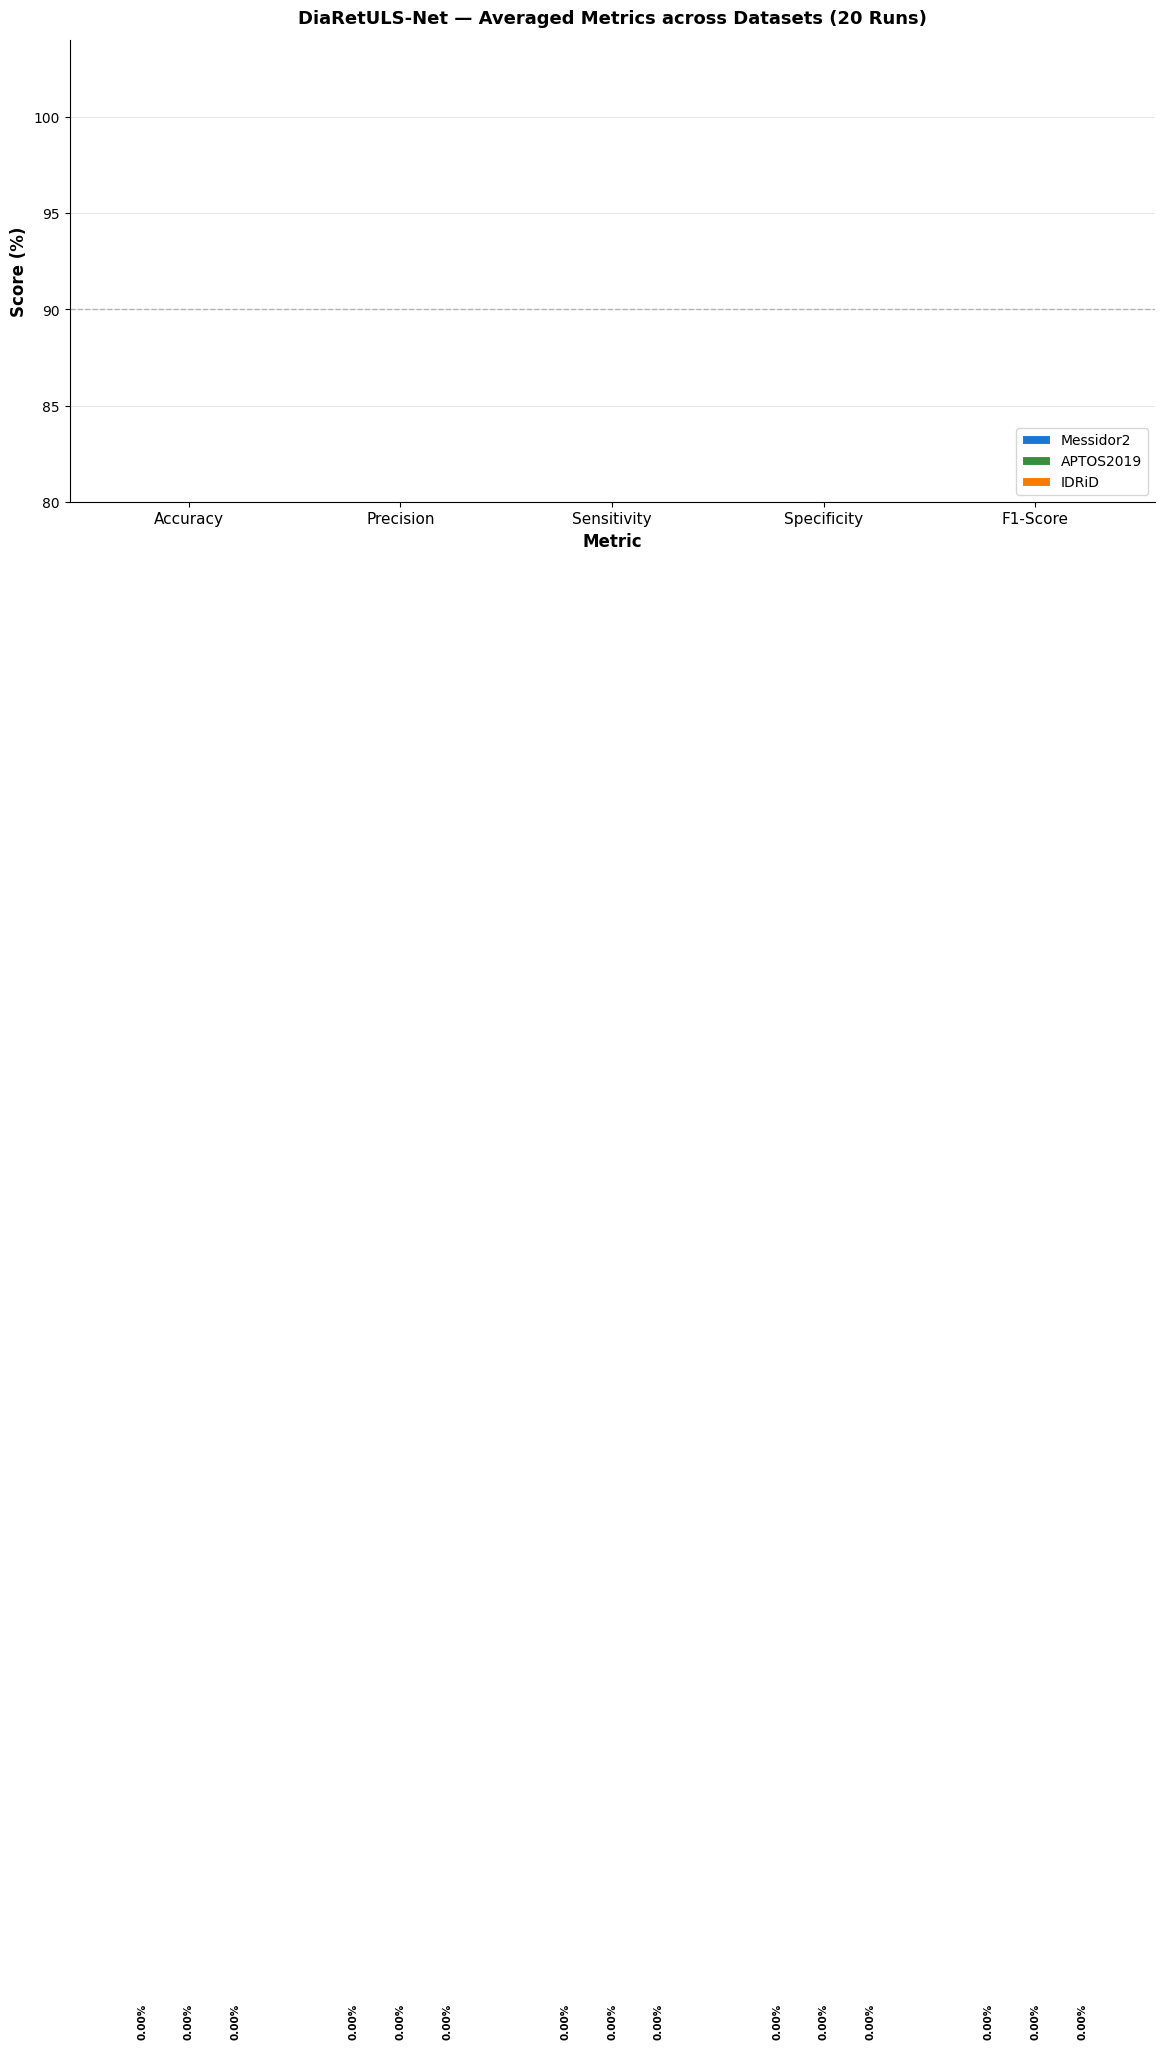

  📁 Chart → /home/user2007/Dr_retinopathy/Results/DiaRetULS_Net_bar_chart.png

  MODEL  : VGG19
  DATASET: Messidor2
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading Messidor-2 from /home/user2007/Dr_retinopathy/data/messidor2

  ✘ VGG19 × Messidor2 FAILED:

  MODEL  : VGG19
  DATASET: APTOS2019
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading APTOS 2019 from /home/user2007/Dr_retinopathy/data/aptos2019

  ✘ VGG19 × APTOS2019 FAILED:

  MODEL  : VGG19
  DATASET: IDRiD
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading IDRiD from /home/user2007/Dr_retinopathy/data/idrid

  ✘ VGG19 × IDRiD FAILED:


Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 91, in load_messidor2
    raise FileNotFoundError(f"No CSV found under {root}")
FileNotFoundError: No CSV found under /home/user2007/Dr_retinopathy/data/messidor2
Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 132, in load_aptos2019
    raise FileNotFoundError(f"No CSV under {root}")
FileNotFoundError: No CSV under /hom

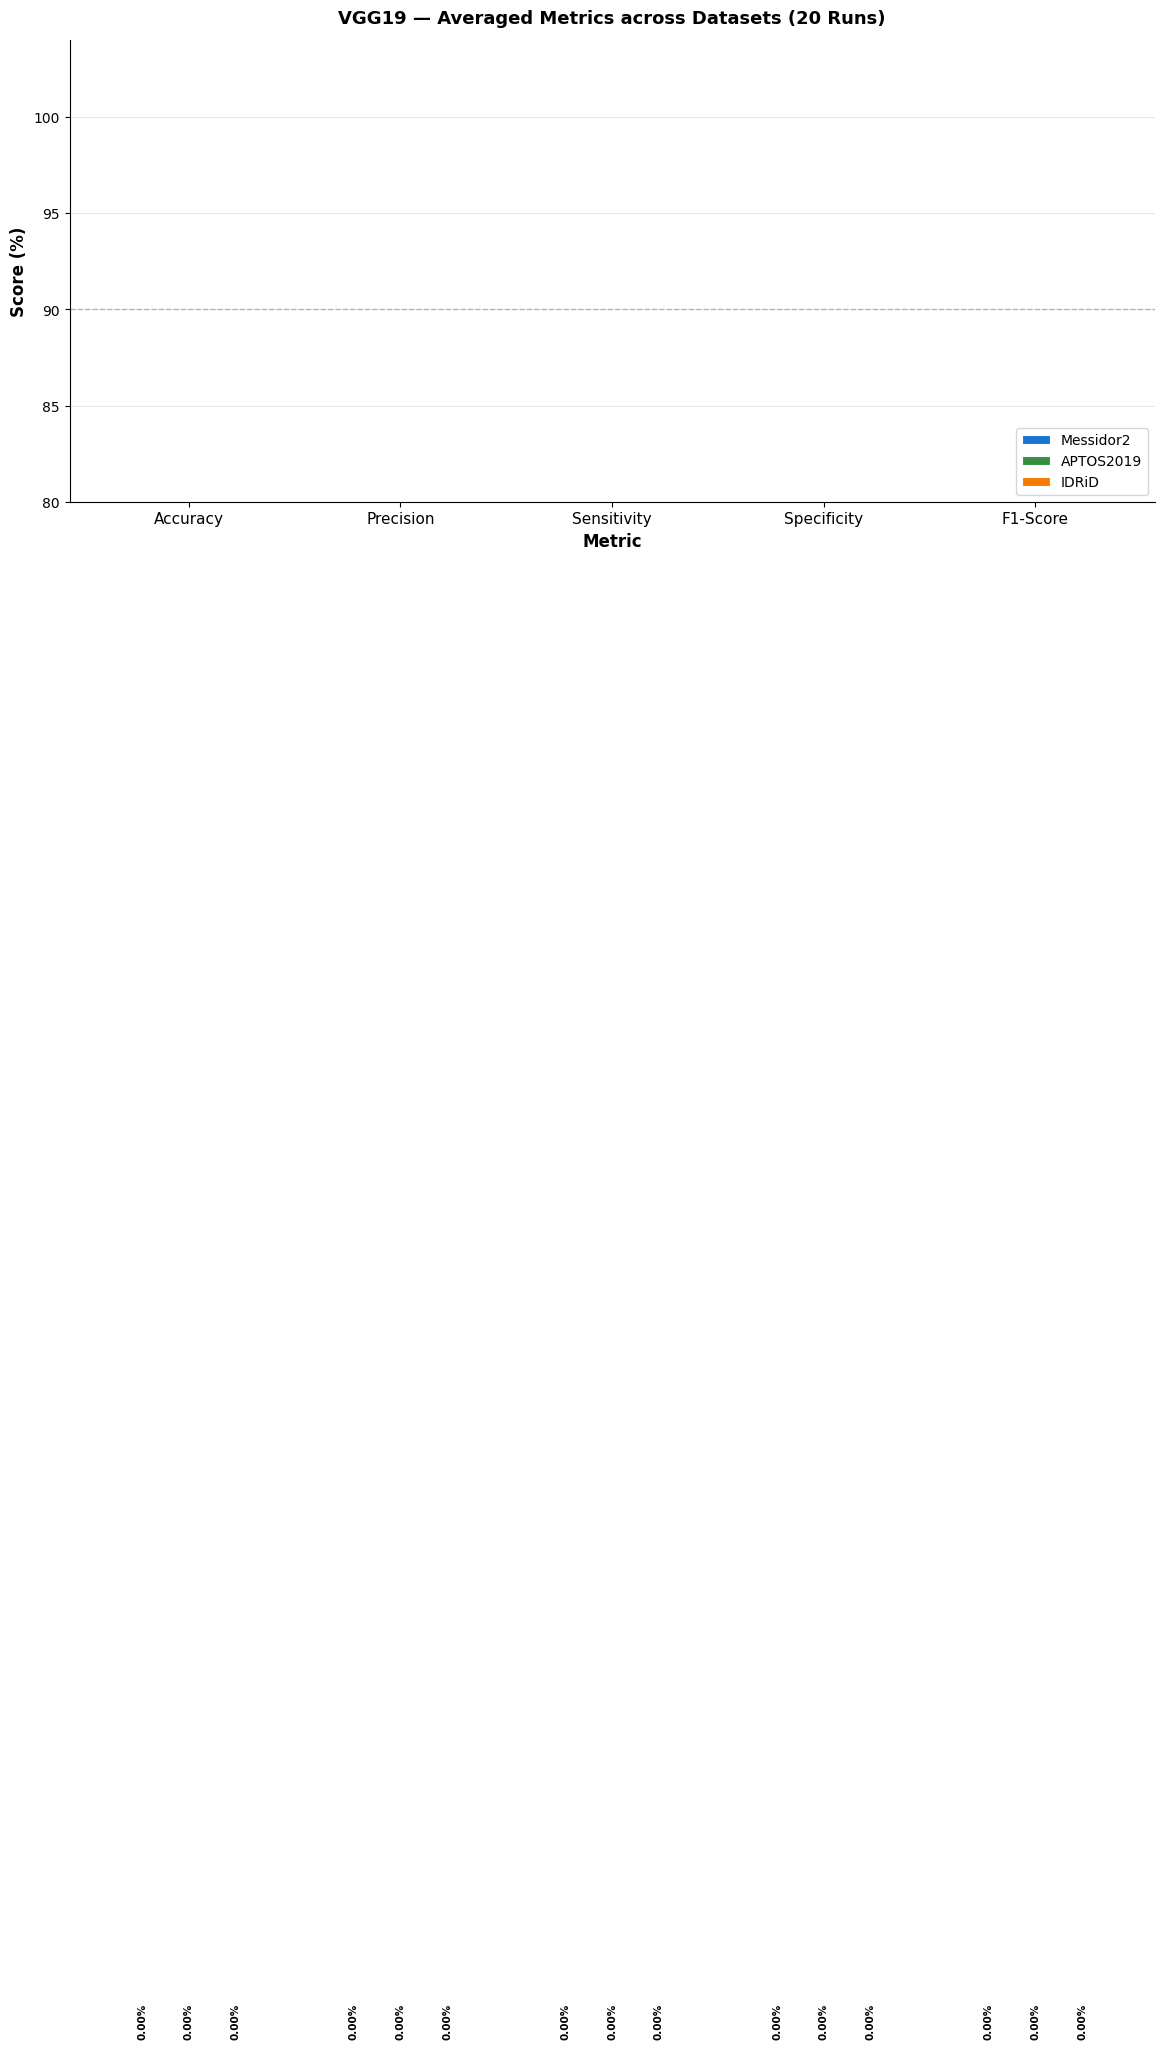

  📁 Chart → /home/user2007/Dr_retinopathy/Results/VGG19_bar_chart.png

  MODEL  : LSTM
  DATASET: Messidor2
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading Messidor-2 from /home/user2007/Dr_retinopathy/data/messidor2

  ✘ LSTM × Messidor2 FAILED:

  MODEL  : LSTM
  DATASET: APTOS2019
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading APTOS 2019 from /home/user2007/Dr_retinopathy/data/aptos2019

  ✘ LSTM × APTOS2019 FAILED:

  MODEL  : LSTM
  DATASET: IDRiD
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading IDRiD from /home/user2007/Dr_retinopathy/data/idrid

  ✘ LSTM × IDRiD FAILED:


Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 91, in load_messidor2
    raise FileNotFoundError(f"No CSV found under {root}")
FileNotFoundError: No CSV found under /home/user2007/Dr_retinopathy/data/messidor2
Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 132, in load_aptos2019
    raise FileNotFoundError(f"No CSV under {root}")
FileNotFoundError: No CSV under /hom

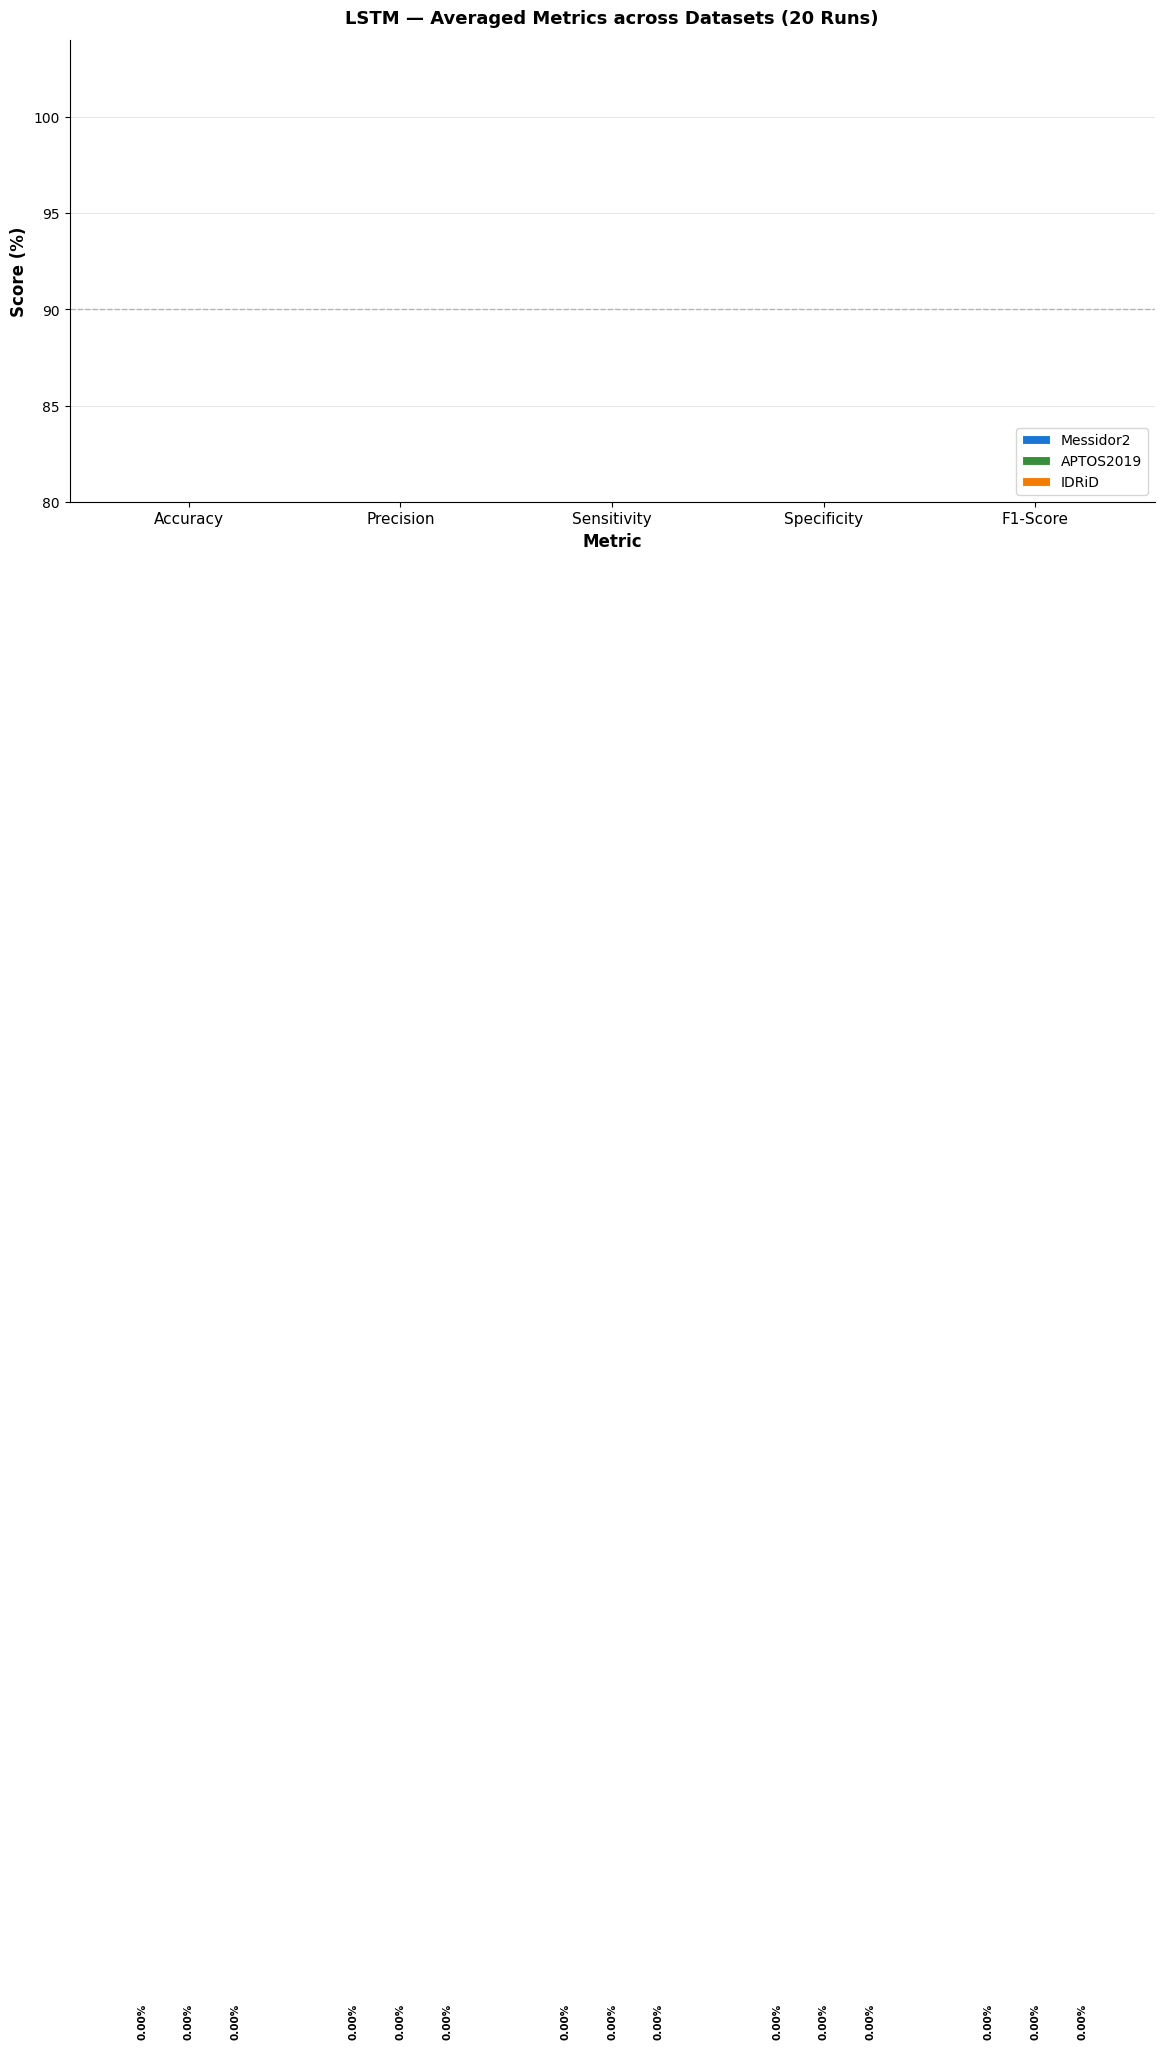

  📁 Chart → /home/user2007/Dr_retinopathy/Results/LSTM_bar_chart.png

  MODEL  : AlexNet
  DATASET: Messidor2
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading Messidor-2 from /home/user2007/Dr_retinopathy/data/messidor2

  ✘ AlexNet × Messidor2 FAILED:

  MODEL  : AlexNet
  DATASET: APTOS2019
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading APTOS 2019 from /home/user2007/Dr_retinopathy/data/aptos2019

  ✘ AlexNet × APTOS2019 FAILED:

  MODEL  : AlexNet
  DATASET: IDRiD
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading IDRiD from /home/user2007/Dr_retinopathy/data/idrid

  ✘ AlexNet × IDRiD FAILED:


Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 91, in load_messidor2
    raise FileNotFoundError(f"No CSV found under {root}")
FileNotFoundError: No CSV found under /home/user2007/Dr_retinopathy/data/messidor2
Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 132, in load_aptos2019
    raise FileNotFoundError(f"No CSV under {root}")
FileNotFoundError: No CSV under /hom

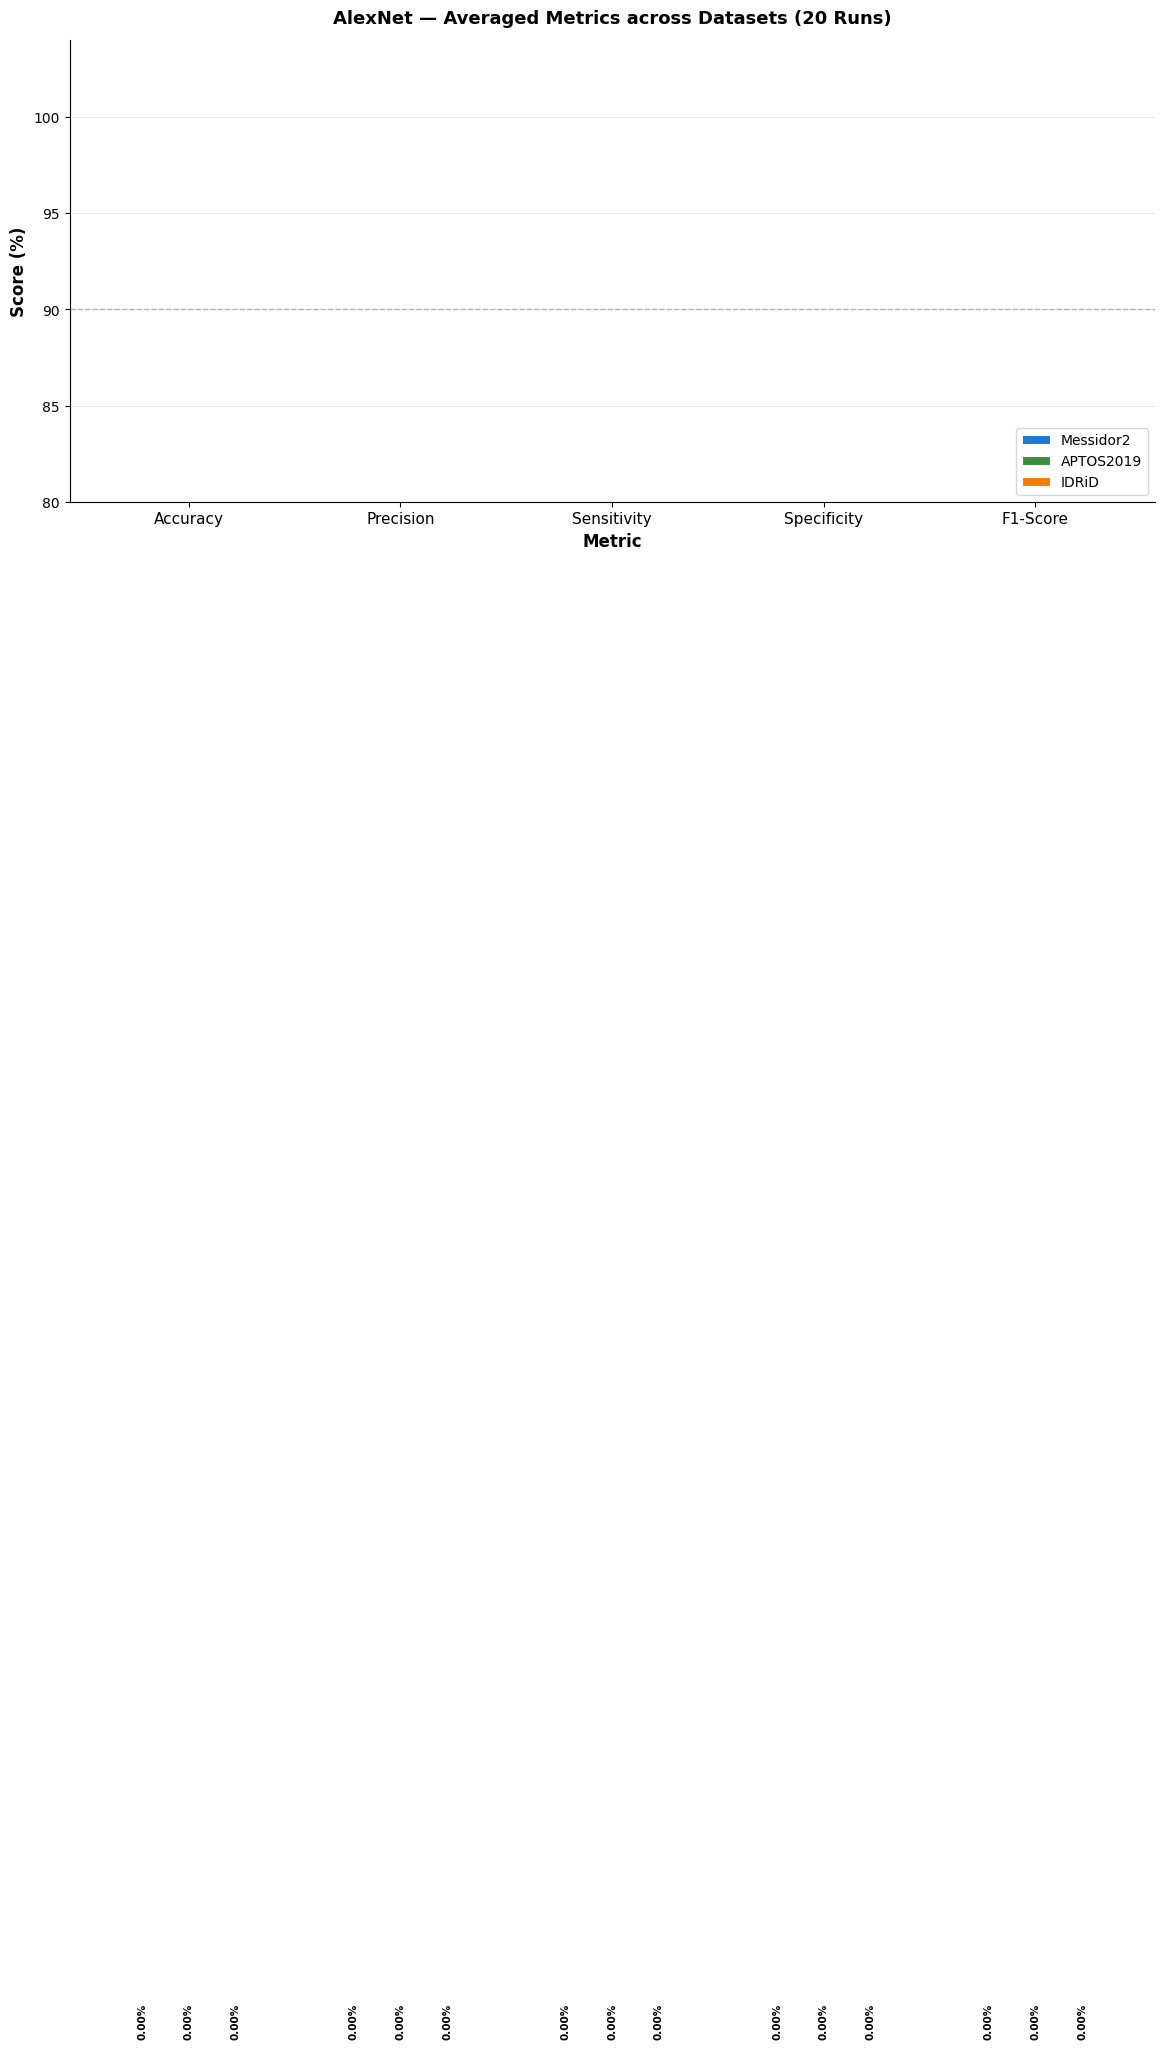

  📁 Chart → /home/user2007/Dr_retinopathy/Results/AlexNet_bar_chart.png

  MODEL  : InceptionV3
  DATASET: Messidor2
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading Messidor-2 from /home/user2007/Dr_retinopathy/data/messidor2

  ✘ InceptionV3 × Messidor2 FAILED:

  MODEL  : InceptionV3
  DATASET: APTOS2019
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading APTOS 2019 from /home/user2007/Dr_retinopathy/data/aptos2019

  ✘ InceptionV3 × APTOS2019 FAILED:

  MODEL  : InceptionV3
  DATASET: IDRiD
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading IDRiD from /home/user2007/Dr_retinopathy/data/idrid

  ✘ InceptionV3 × IDRiD FAILED:


Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 91, in load_messidor2
    raise FileNotFoundError(f"No CSV found under {root}")
FileNotFoundError: No CSV found under /home/user2007/Dr_retinopathy/data/messidor2
Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 132, in load_aptos2019
    raise FileNotFoundError(f"No CSV under {root}")
FileNotFoundError: No CSV under /hom

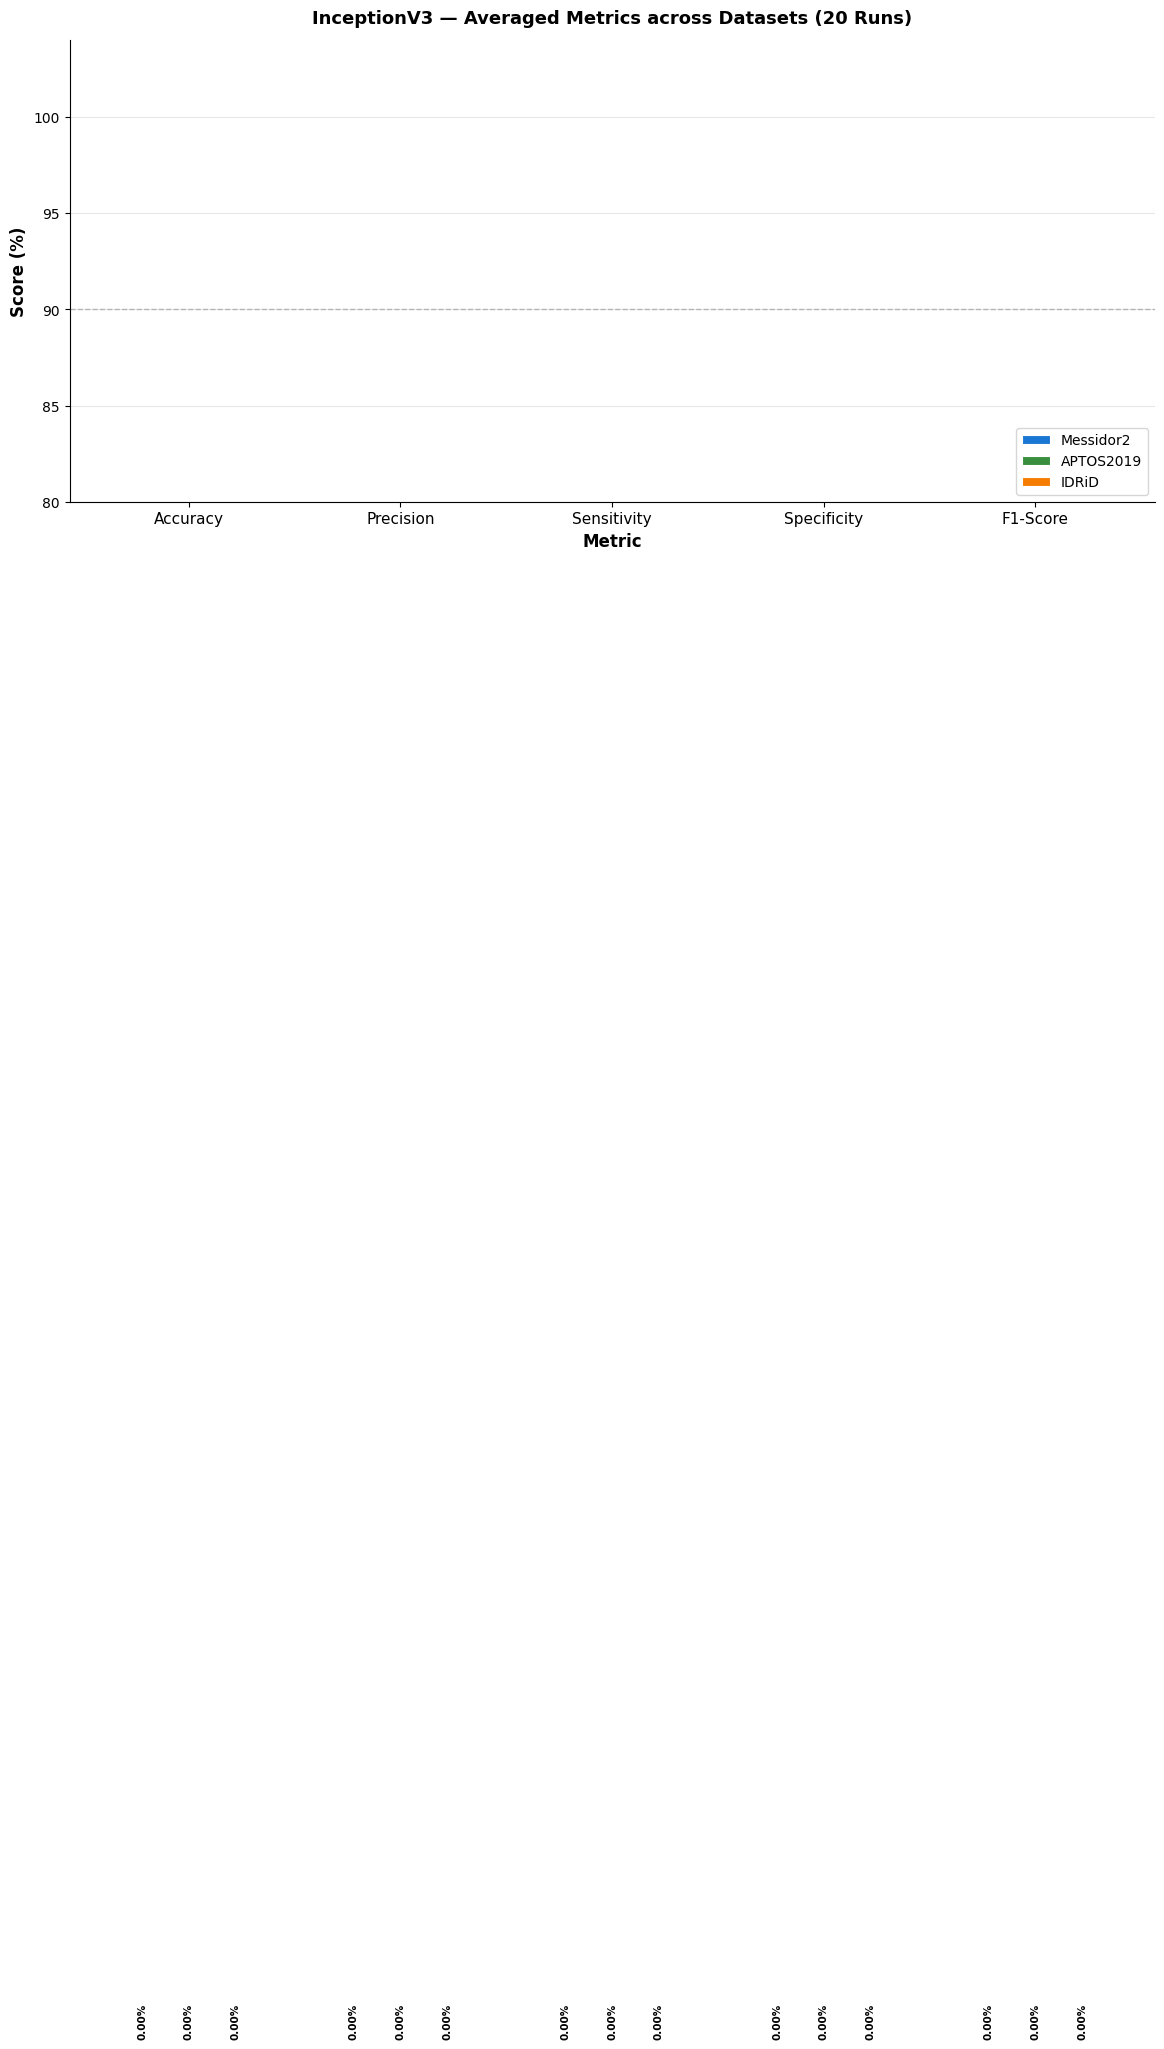

  📁 Chart → /home/user2007/Dr_retinopathy/Results/InceptionV3_bar_chart.png

  MODEL  : ResNet50
  DATASET: Messidor2
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading Messidor-2 from /home/user2007/Dr_retinopathy/data/messidor2

  ✘ ResNet50 × Messidor2 FAILED:

  MODEL  : ResNet50
  DATASET: APTOS2019
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading APTOS 2019 from /home/user2007/Dr_retinopathy/data/aptos2019

  ✘ ResNet50 × APTOS2019 FAILED:

  MODEL  : ResNet50
  DATASET: IDRiD
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading IDRiD from /home/user2007/Dr_retinopathy/data/idrid

  ✘ ResNet50 × IDRiD FAILED:


Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 91, in load_messidor2
    raise FileNotFoundError(f"No CSV found under {root}")
FileNotFoundError: No CSV found under /home/user2007/Dr_retinopathy/data/messidor2
Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 132, in load_aptos2019
    raise FileNotFoundError(f"No CSV under {root}")
FileNotFoundError: No CSV under /hom

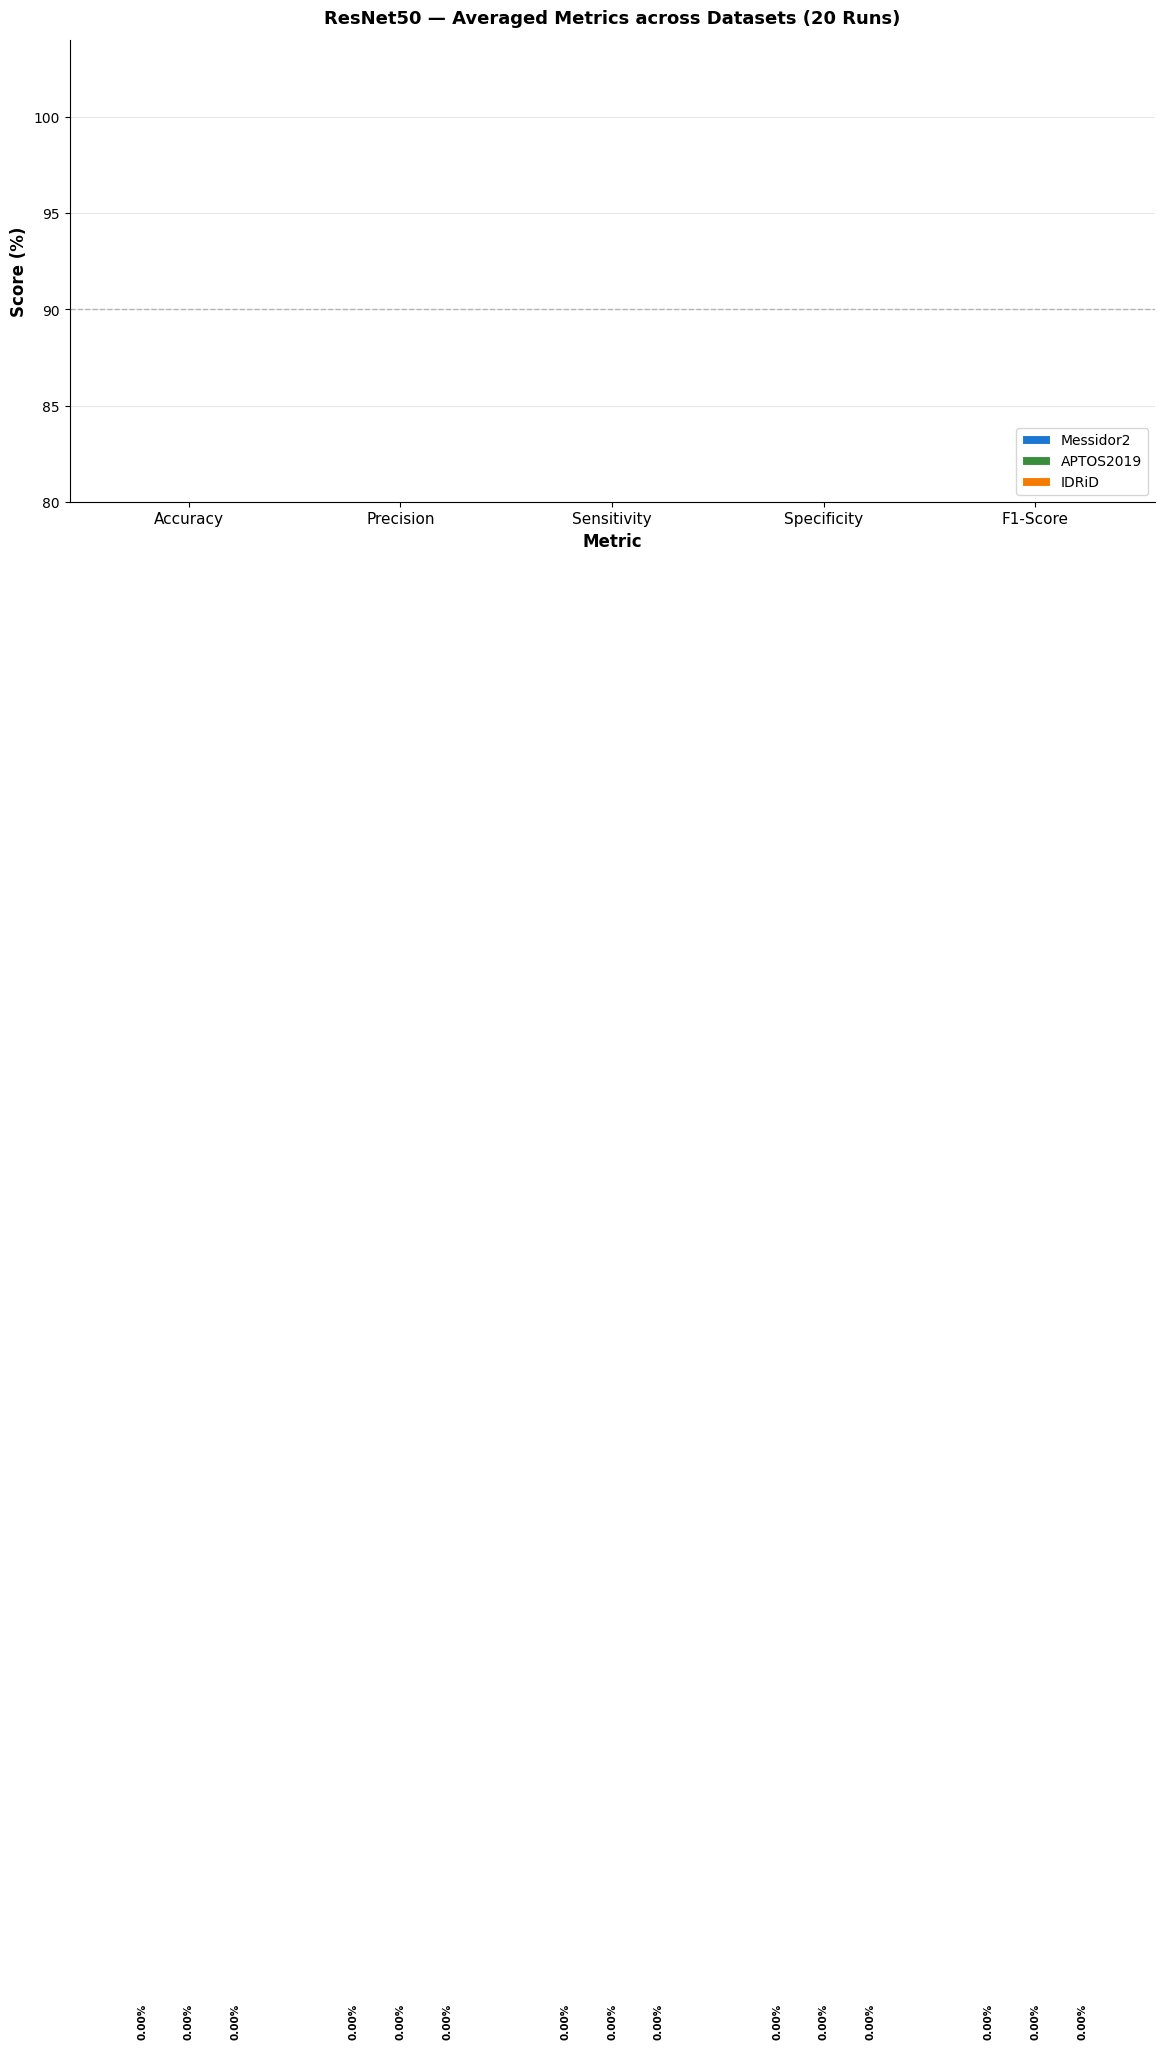

  📁 Chart → /home/user2007/Dr_retinopathy/Results/ResNet50_bar_chart.png

  MODEL  : DenseNet121
  DATASET: Messidor2
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading Messidor-2 from /home/user2007/Dr_retinopathy/data/messidor2

  ✘ DenseNet121 × Messidor2 FAILED:

  MODEL  : DenseNet121
  DATASET: APTOS2019
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading APTOS 2019 from /home/user2007/Dr_retinopathy/data/aptos2019

  ✘ DenseNet121 × APTOS2019 FAILED:

  MODEL  : DenseNet121
  DATASET: IDRiD
  RUNS   : 20 × 5-Fold × 3 Seeds = 300 total models
  Loading IDRiD from /home/user2007/Dr_retinopathy/data/idrid

  ✘ DenseNet121 × IDRiD FAILED:


Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 91, in load_messidor2
    raise FileNotFoundError(f"No CSV found under {root}")
FileNotFoundError: No CSV found under /home/user2007/Dr_retinopathy/data/messidor2
Traceback (most recent call last):
  File "/tmp/ipykernel_1518518/1551711000.py", line 11, in <module>
    avg = run_model_on_dataset(model_name, dataset_name)
  File "/tmp/ipykernel_1518518/1523011287.py", line 21, in run_model_on_dataset
    train_df, val_df, test_df = loader_fn(DATASET_PATHS[dataset_name])
  File "/tmp/ipykernel_1518518/3805986449.py", line 132, in load_aptos2019
    raise FileNotFoundError(f"No CSV under {root}")
FileNotFoundError: No CSV under /hom

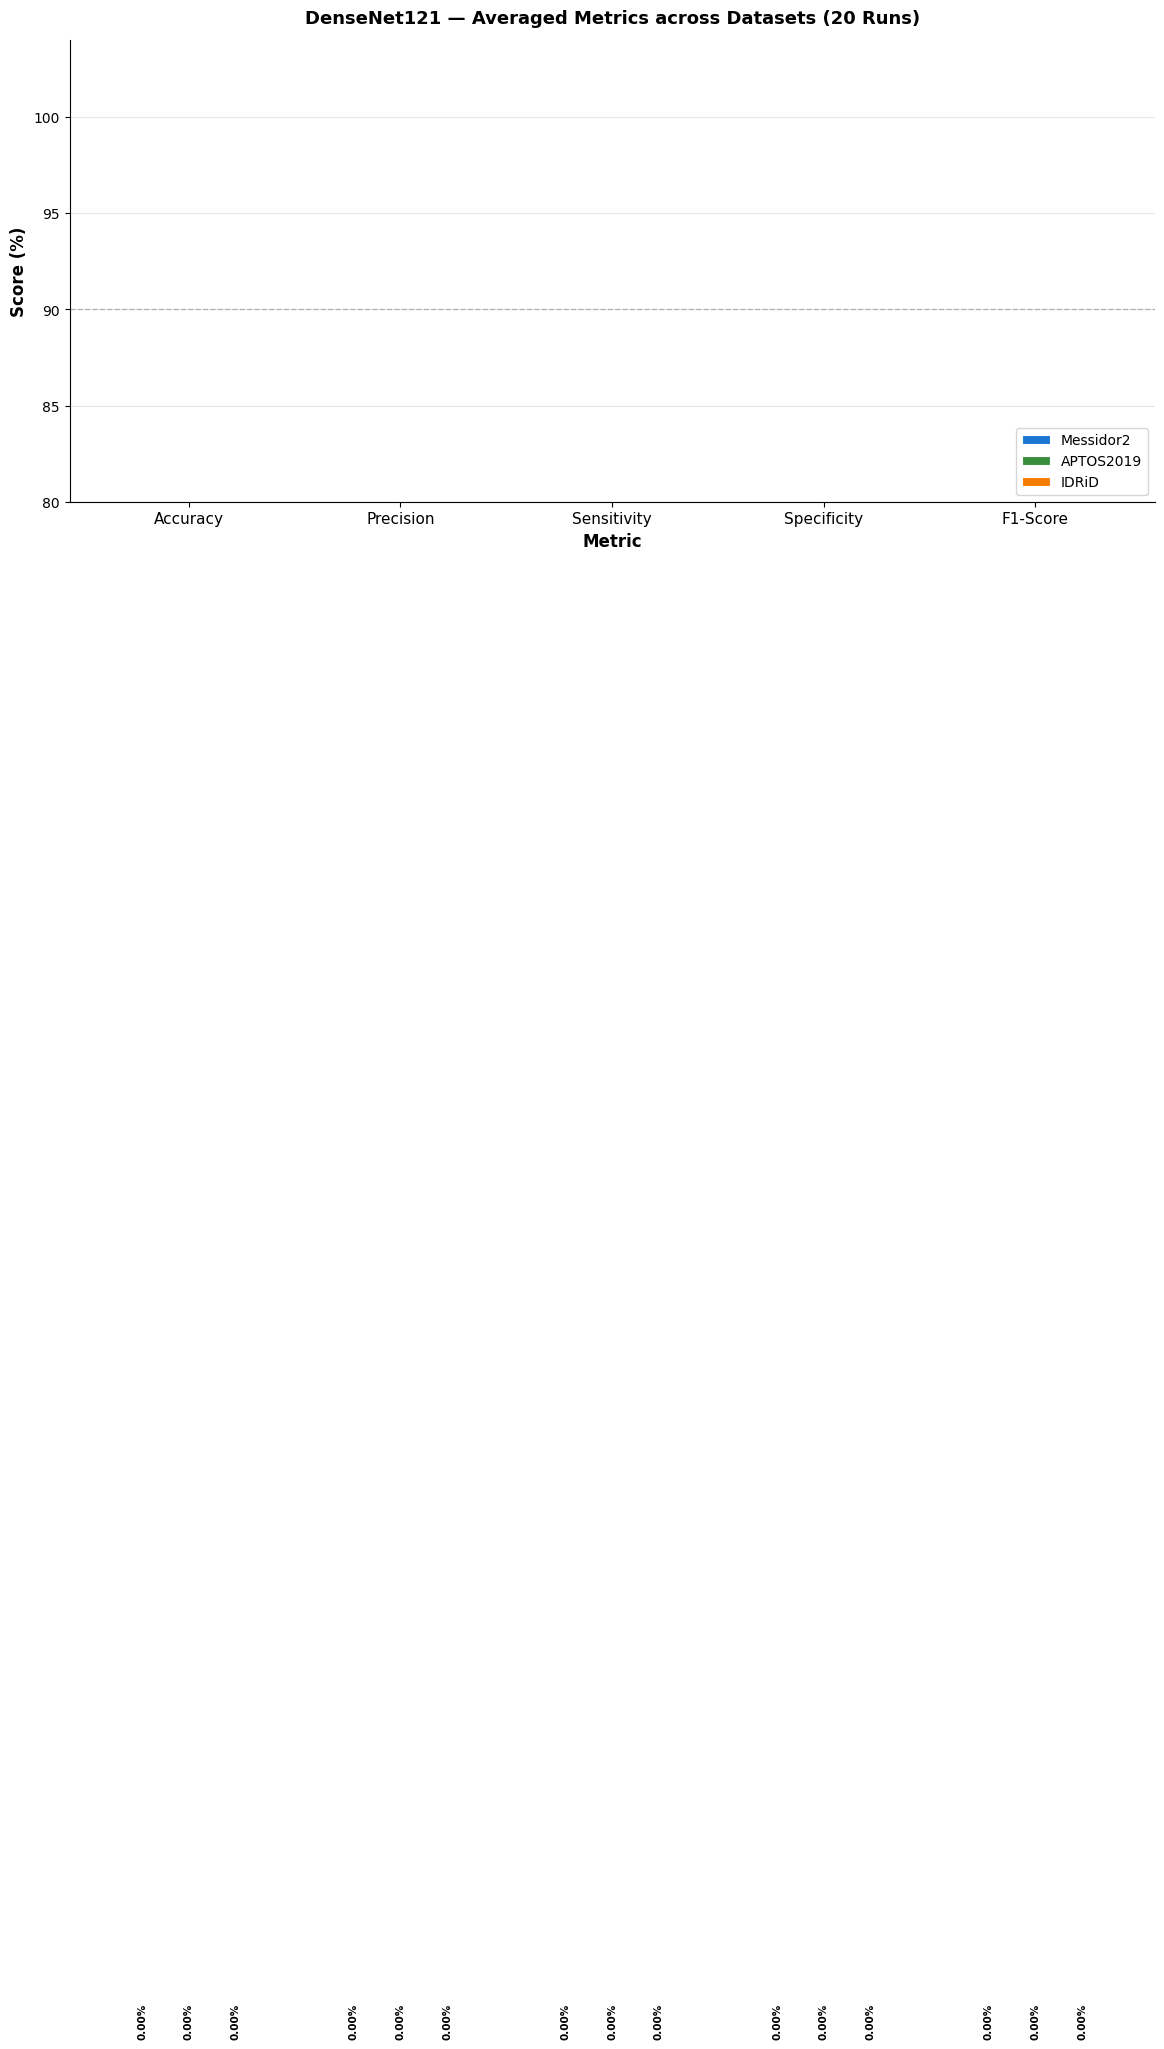

  📁 Chart → /home/user2007/Dr_retinopathy/Results/DenseNet121_bar_chart.png


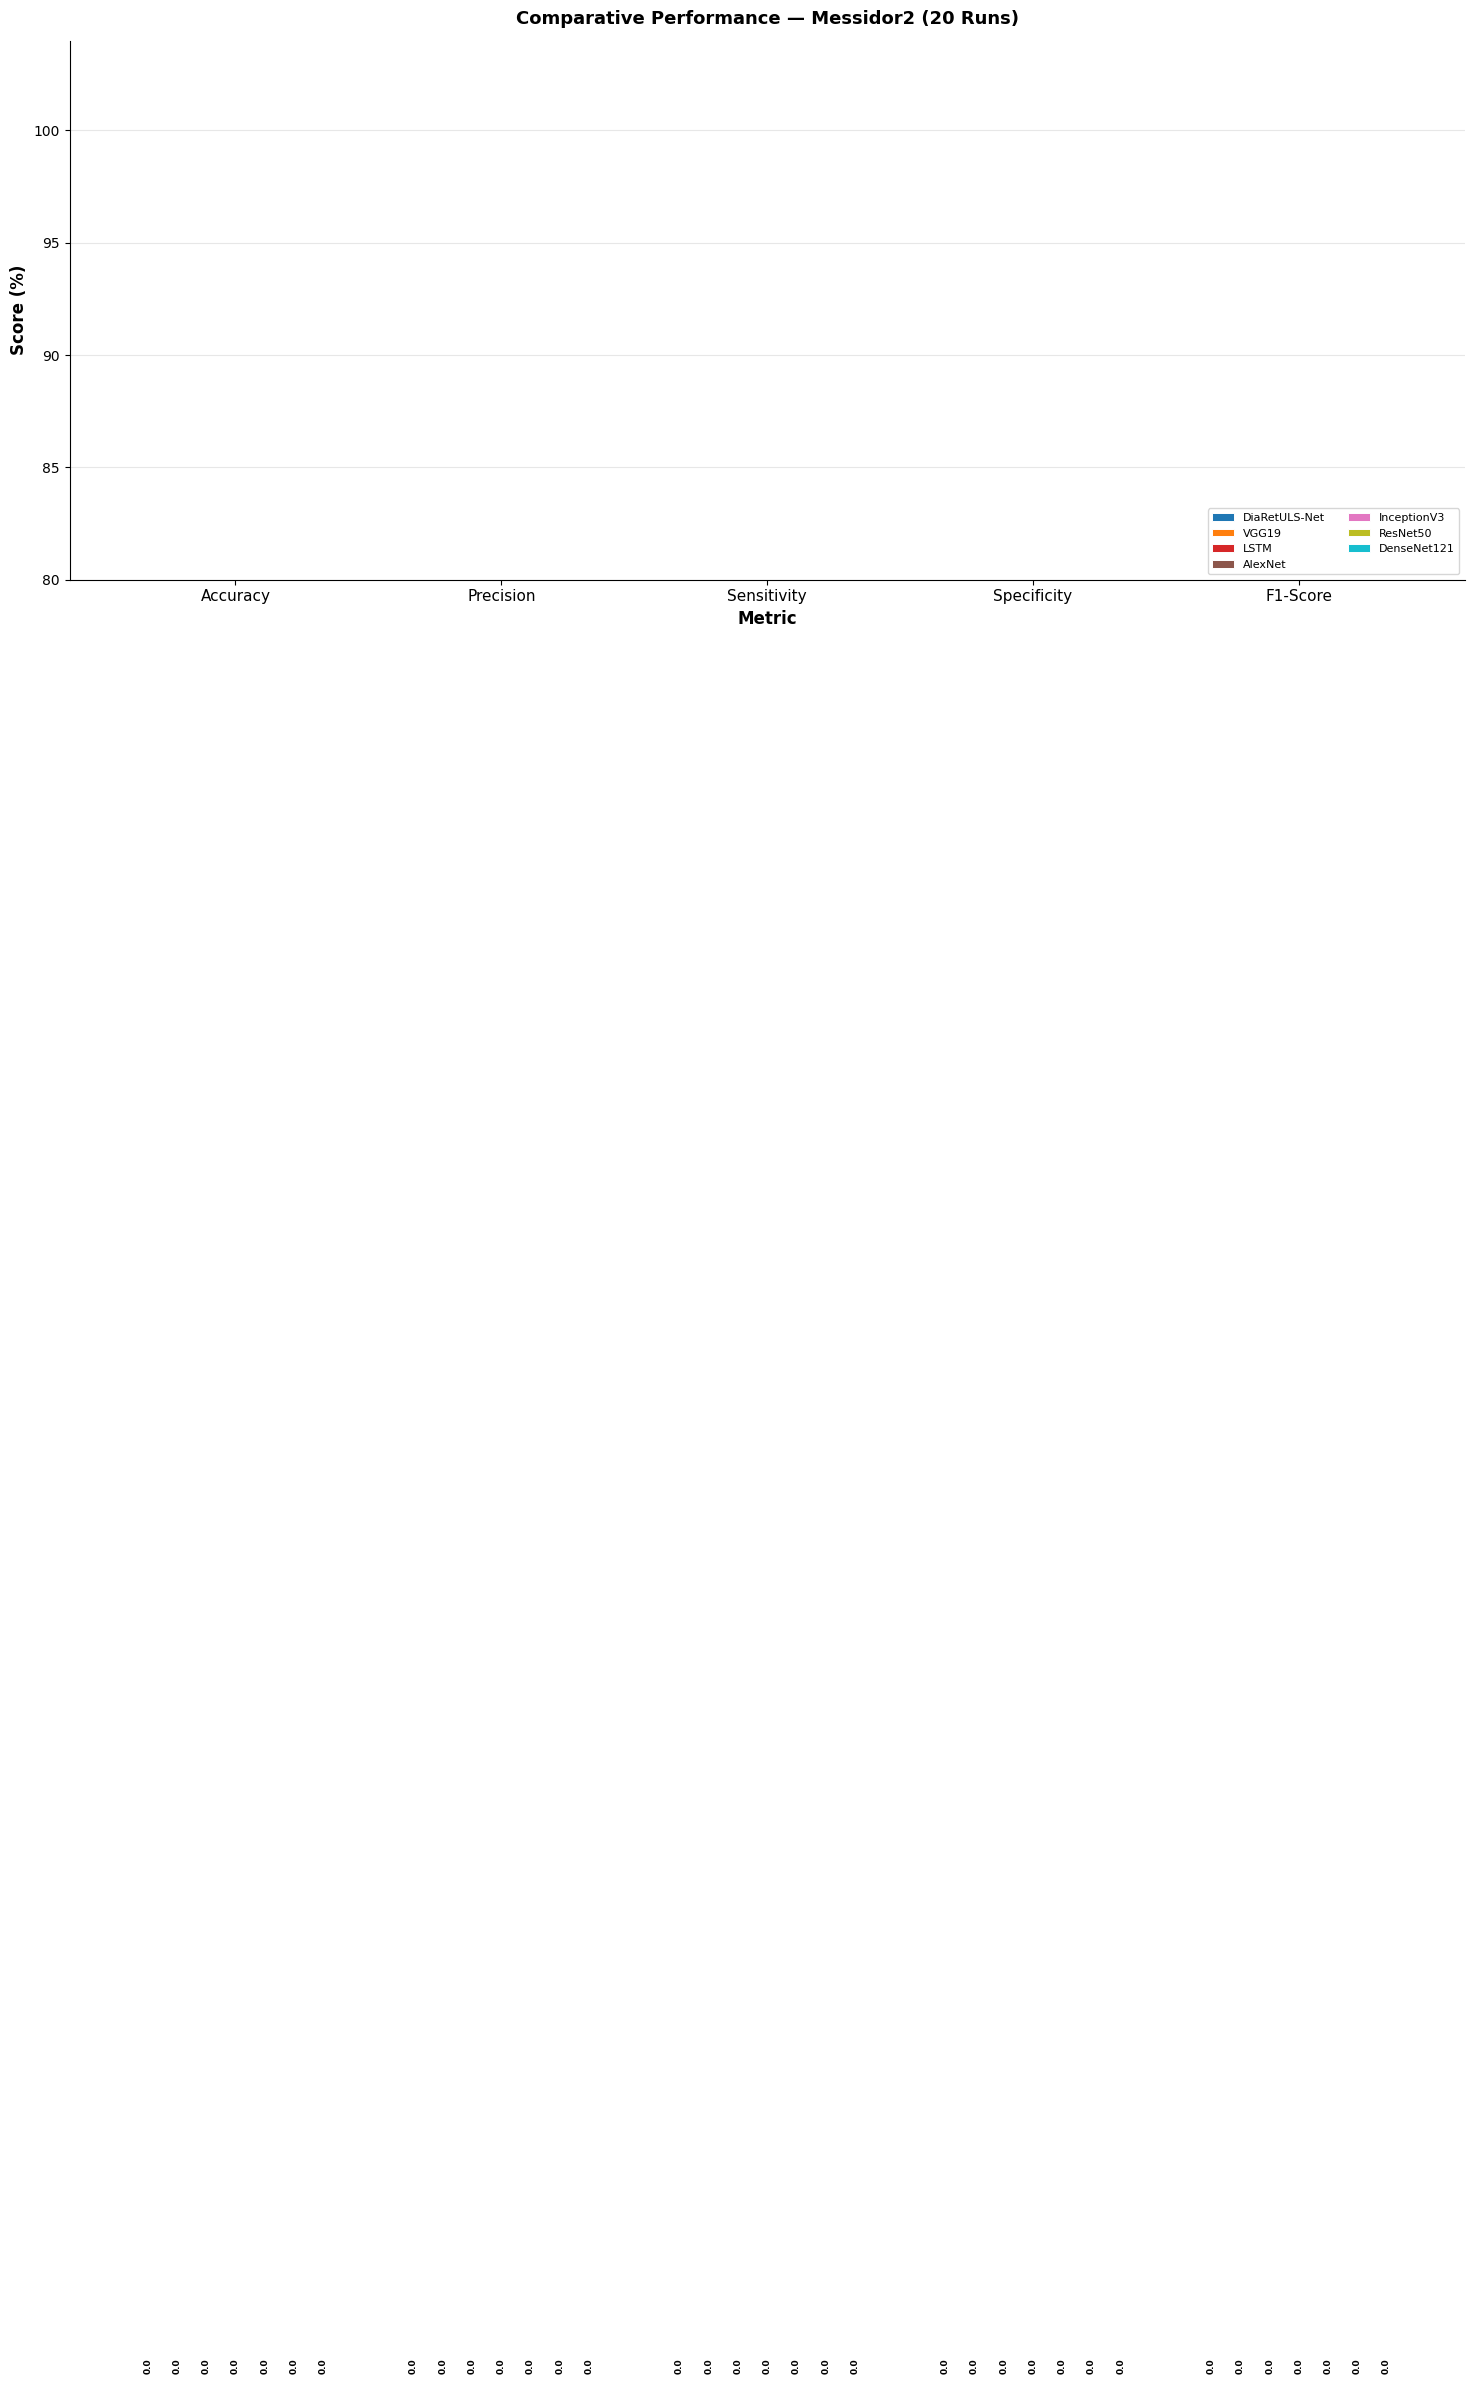

  📁 Comparative chart → /home/user2007/Dr_retinopathy/Results/Comparative_Messidor2.png


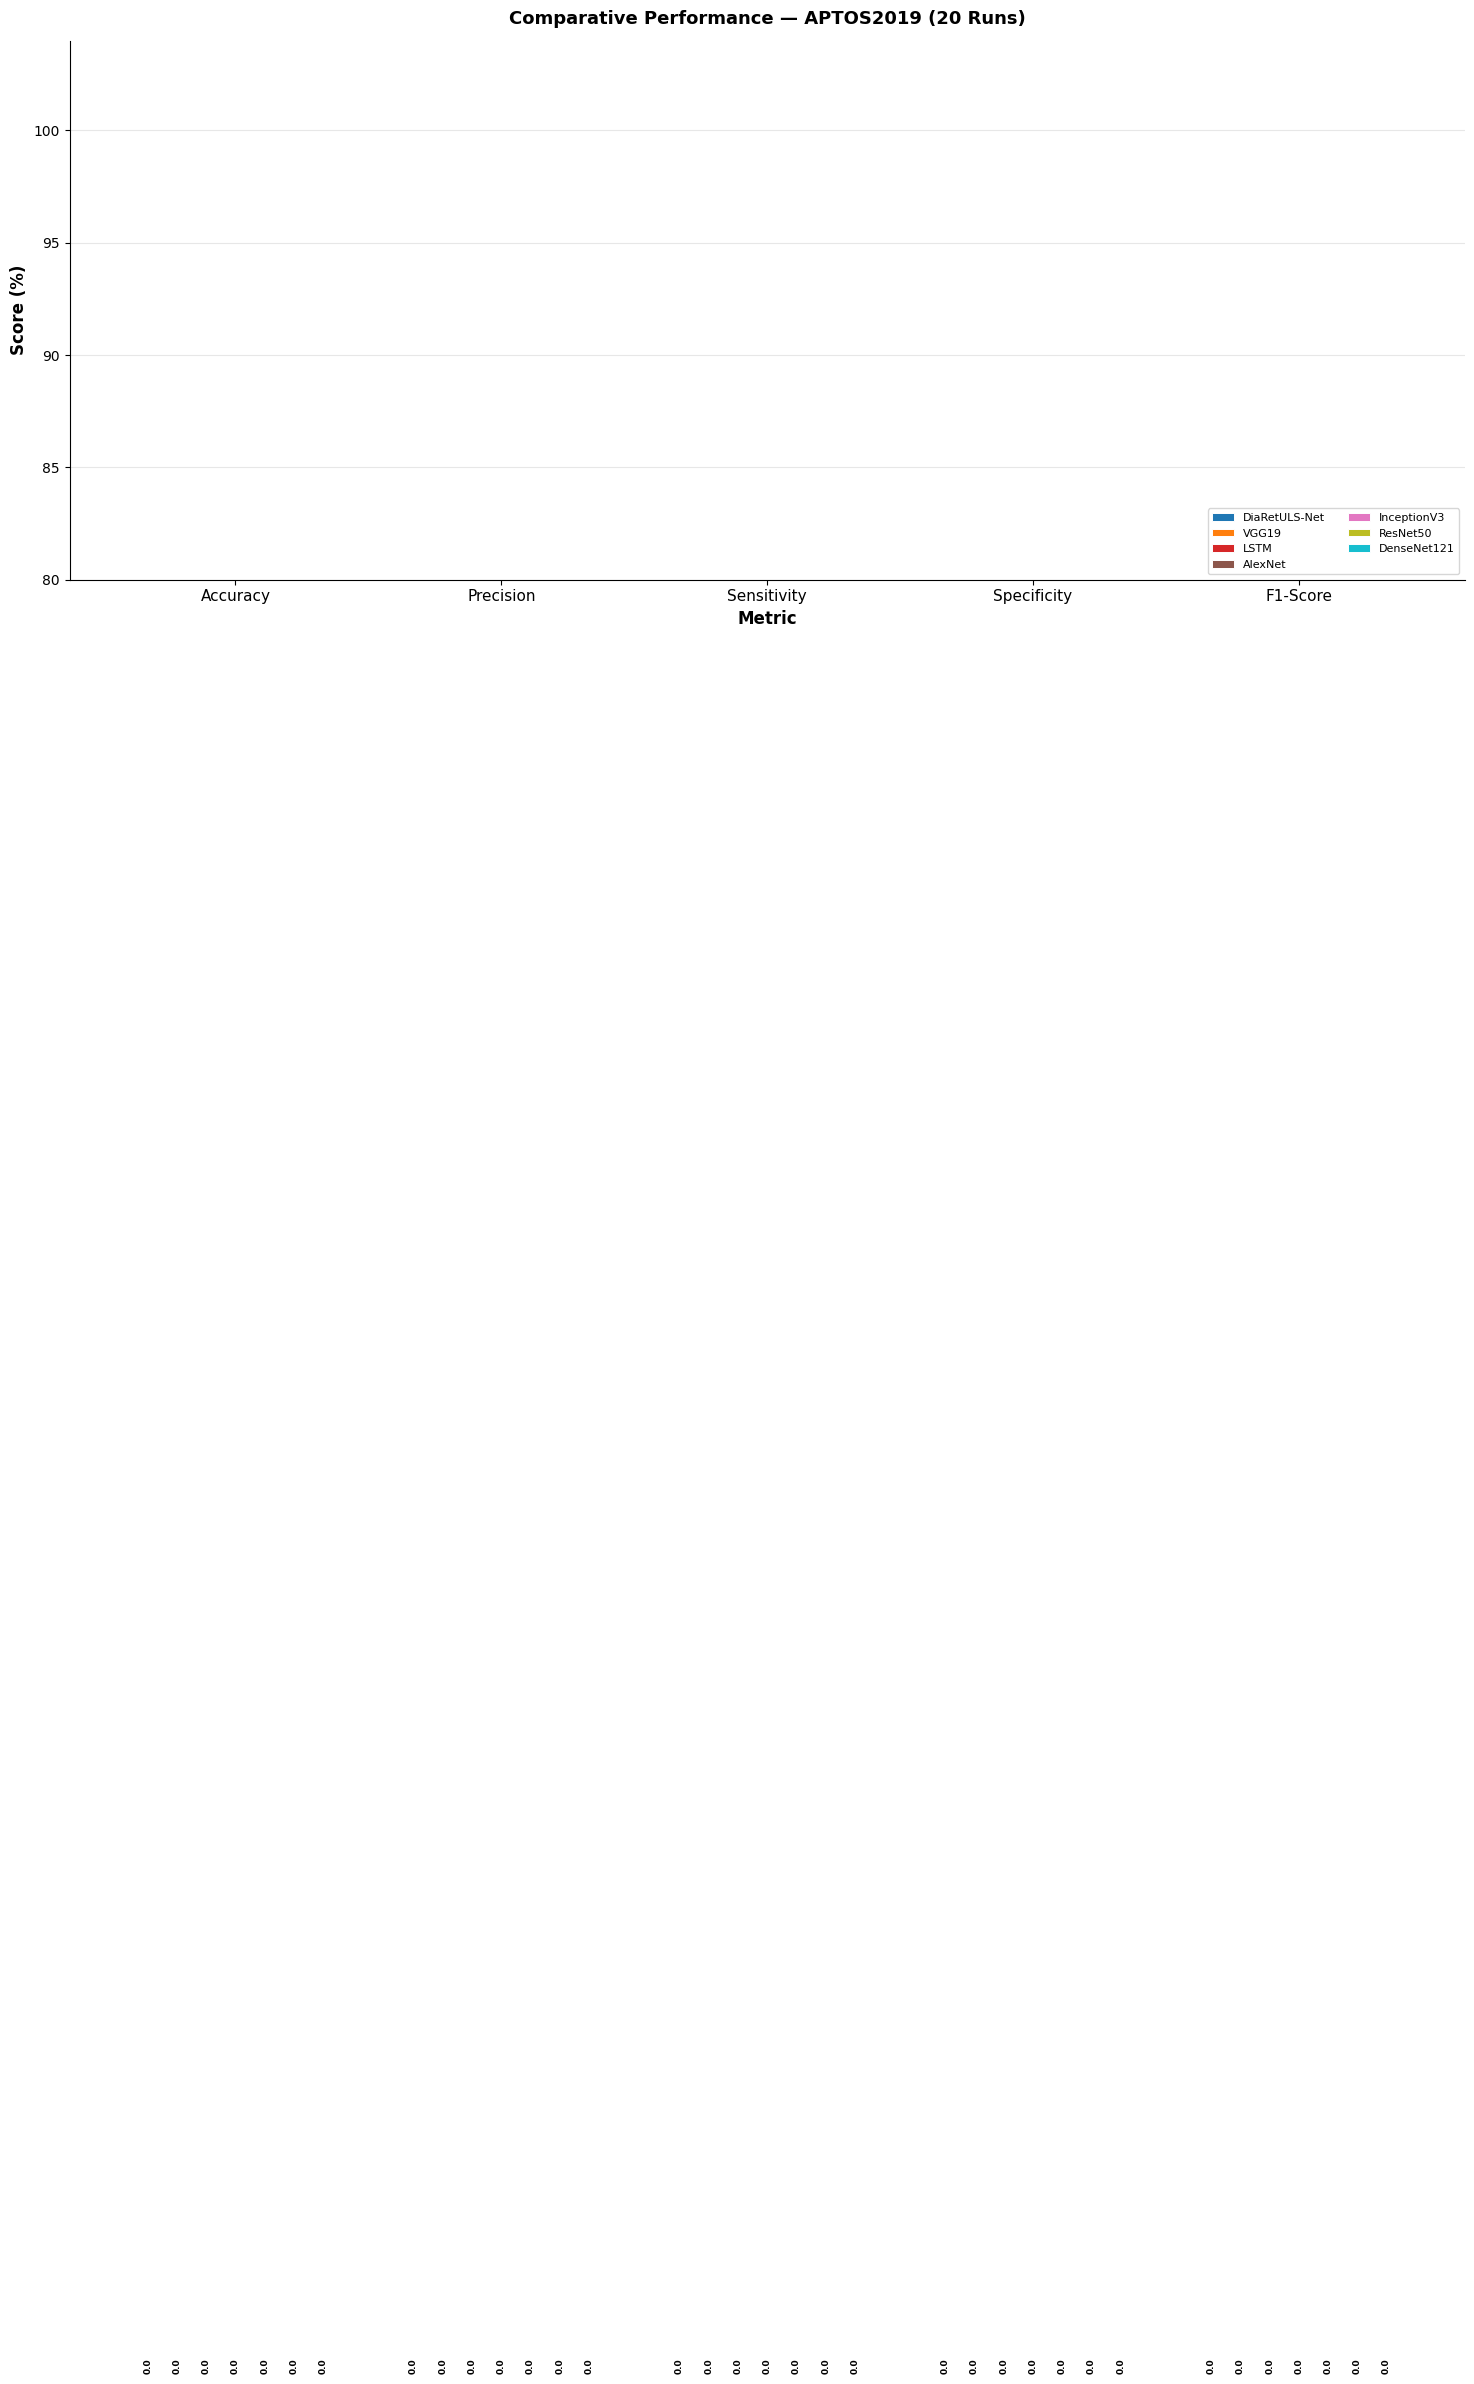

  📁 Comparative chart → /home/user2007/Dr_retinopathy/Results/Comparative_APTOS2019.png


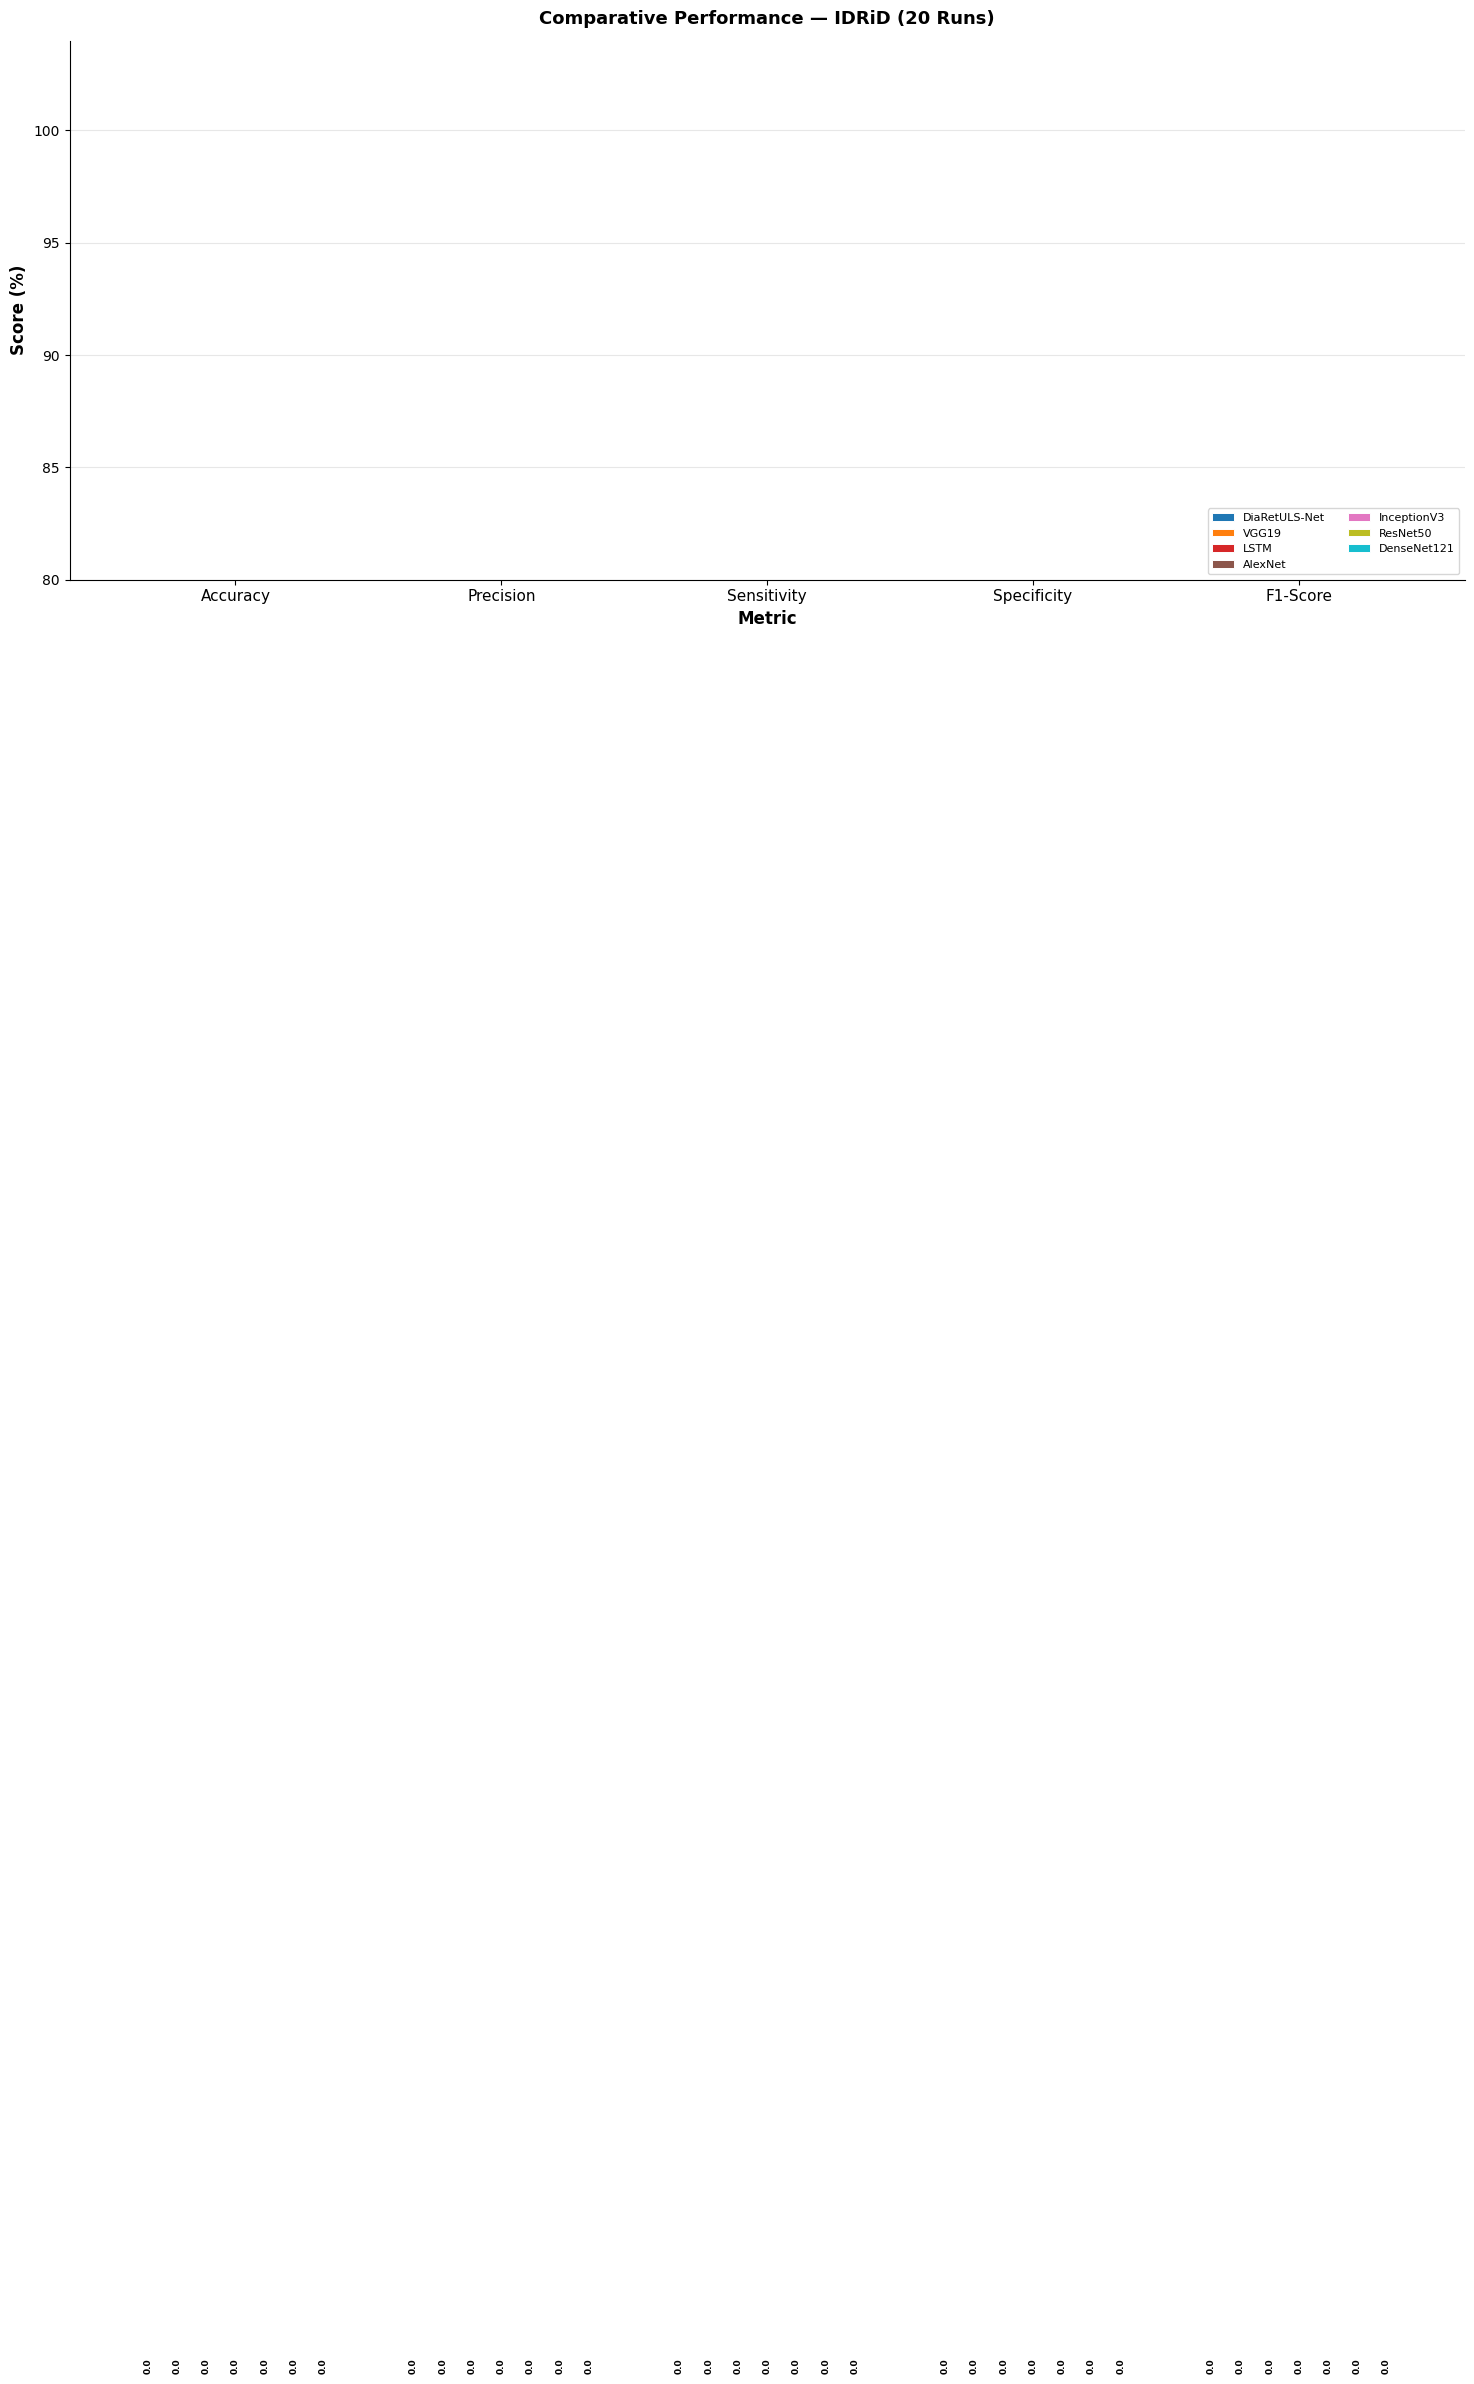

  📁 Comparative chart → /home/user2007/Dr_retinopathy/Results/Comparative_IDRiD.png

✅ CELL 11 complete — all training done!


In [11]:
# ============================================================
# CELL 11 — RUN ALL  (execute this cell to start training)
# ============================================================

import traceback

for model_name in MODELS_TO_RUN:
    results[model_name] = {}
    for dataset_name in DATASETS_TO_RUN:
        try:
            avg = run_model_on_dataset(model_name, dataset_name)
            results[model_name][dataset_name] = avg
        except Exception as exc:
            print(f"\n  ✘ {model_name} × {dataset_name} FAILED:")
            traceback.print_exc()
            results[model_name][dataset_name] = {m: 0.0 for m in METRIC_COLS}

    # ── Per-model bar chart (all 3 datasets) ──────────────────
    if results[model_name]:
        plot_model_metrics_bar(results[model_name], model_name)

# ── Comparative bar charts (all models per dataset) ────────────
for dataset_name in DATASETS_TO_RUN:
    model_avgs = {m: results[m].get(dataset_name, {}) for m in MODELS_TO_RUN
                  if results[m].get(dataset_name)}
    if model_avgs:
        plot_comparative_bar(model_avgs, dataset_name)

print("\n✅ CELL 11 complete — all training done!")



  COMPARATIVE PERFORMANCE OF DiaRetULS-Net AND BASELINE MODELS ACROSS DATASETS
        Model   Dataset Accuracy (%) Precision (%) Sensitivity (%) Specificity (%) F1-Score (%)
DiaRetULS-Net Messidor2         0.00          0.00            0.00            0.00         0.00
DiaRetULS-Net APTOS2019         0.00          0.00            0.00            0.00         0.00
DiaRetULS-Net     IDRiD         0.00          0.00            0.00            0.00         0.00
        VGG19 Messidor2         0.00          0.00            0.00            0.00         0.00
        VGG19 APTOS2019         0.00          0.00            0.00            0.00         0.00
        VGG19     IDRiD         0.00          0.00            0.00            0.00         0.00
         LSTM Messidor2         0.00          0.00            0.00            0.00         0.00
         LSTM APTOS2019         0.00          0.00            0.00            0.00         0.00
         LSTM     IDRiD         0.00          0.00      

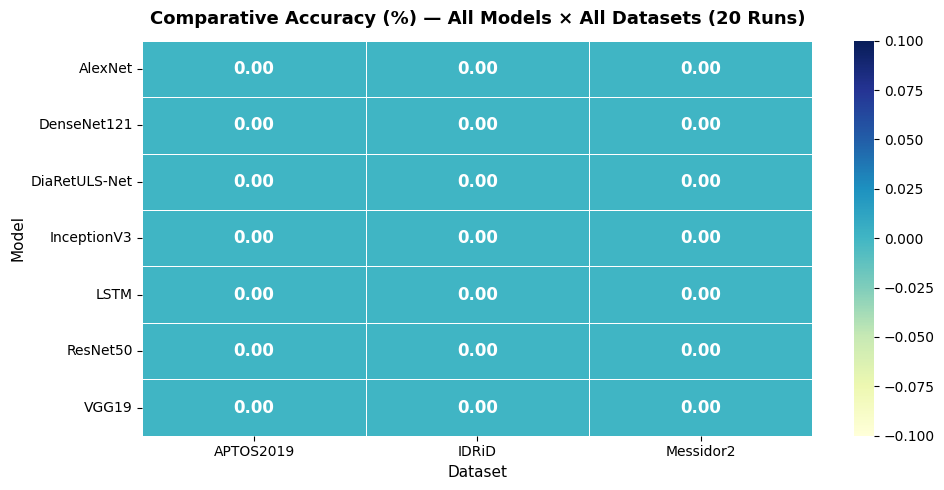

  📁 Heatmap → /home/user2007/Dr_retinopathy/Results/Heatmap_Accuracy.png


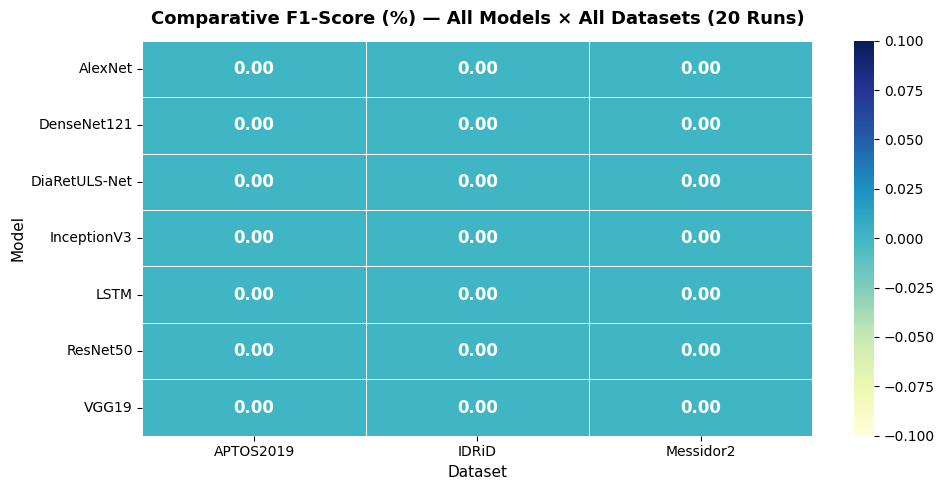

  📁 Heatmap → /home/user2007/Dr_retinopathy/Results/Heatmap_F1-Score.png

  Per-model CSV files:

✅ CELL 12 complete — ALL DONE!


In [12]:
# ============================================================
# CELL 12 — FINAL SUMMARY TABLE
# Prints and saves the full comparative performance table
# exactly matching the paper's format
# ============================================================

rows = []
for model_name in MODELS_TO_RUN:
    for dataset_name in DATASETS_TO_RUN:
        avg = results.get(model_name, {}).get(dataset_name, {})
        if avg:
            rows.append({
                "Model"         : model_name,
                "Dataset"       : dataset_name,
                "Accuracy (%)"  : f"{avg.get('accuracy',0)*100:.2f}",
                "Precision (%)" : f"{avg.get('precision',0)*100:.2f}",
                "Sensitivity (%)": f"{avg.get('sensitivity',0)*100:.2f}",
                "Specificity (%)": f"{avg.get('specificity',0)*100:.2f}",
                "F1-Score (%)"  : f"{avg.get('f1_score',0)*100:.2f}",
            })

df_summary = pd.DataFrame(rows)
print("\n" + "="*100)
print("  COMPARATIVE PERFORMANCE OF DiaRetULS-Net AND BASELINE MODELS ACROSS DATASETS")
print("="*100)
print(df_summary.to_string(index=False))

# Save final summary CSV
summary_path = os.path.join(OUTPUT_DIR, "Final_Comparative_Performance.csv")
df_summary.to_csv(summary_path, index=False)
print(f"\n  📁 Final summary CSV → {summary_path}")

# ── Final heatmap ──────────────────────────────────────────────
for metric_col, metric_label in zip(["Accuracy (%)", "F1-Score (%)"],
                                     ["Accuracy", "F1-Score"]):
    pivot = df_summary.pivot(index="Model", columns="Dataset", values=metric_col)
    pivot = pivot.astype(float)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu",
                linewidths=0.5, linecolor="white",
                annot_kws={"fontsize": 12, "fontweight": "bold"}, ax=ax)
    ax.set_title(f"Comparative {metric_label} (%) — All Models × All Datasets ({NUM_RUNS} Runs)",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Dataset", fontsize=11); ax.set_ylabel("Model", fontsize=11)
    plt.tight_layout()
    heatmap_path = os.path.join(OUTPUT_DIR, f"Heatmap_{metric_label.replace(' ','_')}.png")
    plt.savefig(heatmap_path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"  📁 Heatmap → {heatmap_path}")
    plt.close()

# ── CSV summary per model ──────────────────────────────────────
print("\n  Per-model CSV files:")
for model_name in MODELS_TO_RUN:
    safe = model_name.replace("-", "_").replace(" ", "_")
    path = os.path.join(OUTPUT_DIR, f"{safe}_metrics.csv")
    if os.path.exists(path):
        df_m = pd.read_csv(path)
        print(f"    {model_name:<18}: {len(df_m)} rows → {path}")

print("\n✅ CELL 12 complete — ALL DONE!")
